# 🤖 Classificação Supervisionada — Visão Geral de Modelos
## Dataset: Bank Marketing — UCI Repository

**Objetivo:** Aplicar e comparar **10 algoritmos de classificação** no dataset de marketing
bancário, avaliando cada um com métricas adequadas para dados desbalanceados.

| # | Algoritmo | Família |
|---|---|---|
| 1 | Regressão Logística | Modelos Lineares |
| 2 | K-Nearest Neighbors (KNN) | Baseado em Instâncias |
| 3 | SVM Linear | Máquinas de Vetores de Suporte |
| 4 | SVM RBF | Máquinas de Vetores de Suporte |
| 5 | Árvore de Decisão | Baseado em Árvores |
| 6 | Random Forest | Ensemble (Bagging) |
| 7 | MLP Classifier | Redes Neurais |
| 8 | AdaBoost | Ensemble (Boosting) |
| 9 | Naive Bayes (Gaussian) | Probabilístico |
| 10 | XGBoost | Extreme Gradient Boosting |

> 💡 Este notebook é um instrumento **didático**. Cada seção apresenta teoria antes da implementação.

---
**Dataset:** 41.188 registros · 19 features (após remover `duration`) · Target: `y` *(subscreveu depósito a prazo?)*
**Desafio:** Classes desbalanceadas — **88,7% `não`** vs **11,3% `sim`**

In [1]:
# ─── Importações ──────────────────────────────────────────────────────────────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import time
import sys

from IPython.display import display

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder, OrdinalEncoder
from sklearn.utils import resample

from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    roc_curve, auc, precision_recall_curve, average_precision_score,
    precision_score, recall_score, f1_score,
)
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression

# XGBoost
try:
    import xgboost as xgb
    XGB_OK = True
    print(f"XGBoost {xgb.__version__} disponivel!")
except ImportError:
    XGB_OK = False
    print("XGBoost nao instalado. Execute: pip install xgboost")

warnings.filterwarnings("ignore")
plt.rcParams.update({"figure.dpi": 110, "font.family": "DejaVu Sans"})
sns.set_style("whitegrid")
print("Bibliotecas carregadas com sucesso!")

XGBoost 3.2.0 disponivel!
Bibliotecas carregadas com sucesso!


In [2]:
# Desconmente a linha abaixo caso o XGBoost não esteja instalado
#! pip install xgboost

---
# 1. 🧩 Classificação Supervisionada

## O que é Classificação?

A **classificação** é uma tarefa de aprendizado supervisionado cujo objetivo é atribuir uma
**rótulo (classe)** a cada observação com base em suas características (features).

No Bank Marketing, o problema é binário: dado o perfil de um cliente e o contexto econômico,
prever se ele irá ou não subscrever um depósito a prazo (`y = sim` ou `y = não`).

## Interface Padrão do Scikit-Learn

Todos os classificadores do sklearn seguem a mesma interface. Isso permite substituir um
algoritmo por outro com apenas uma linha de código:

| Método | Descrição |
|---|---|
| `fit(X, y)` | Treinar o modelo com os dados e labels |
| `predict(X)` | Prever a classe (0 ou 1) para novas observações |
| `predict_proba(X)` | Prever a **probabilidade** de cada classe (onde disponível) |
| `predict_log_proba(X)` | Log da probabilidade (para estabilidade numérica) |
| `score(X, y)` | Acurácia do modelo nos dados fornecidos |

### Estrutura padrão de um experimento:

```python
# 1. Instanciar
clf = AlgoritmoClassifier(hiperparametros)

# 2. Treinar
clf.fit(X_train, y_train)

# 3. Predizer
y_pred = clf.predict(X_test)

# 4. Avaliar
acc = accuracy_score(y_test, y_pred)
print(classification_report(y_test, y_pred))
```

> ⚠️ **Dados (X):** matriz (m × n) — m amostras, n features
> **Labels (y):** vetor de tamanho m com a classe de cada amostra

In [3]:
# ─── Carga do Dataset ─────────────────────────────────────────────────────────
IN_COLAB = "google.colab" in sys.modules
if IN_COLAB:
    from google.colab import files
    print("Colab: faca upload do arquivo bank-additional-full.csv")
    uploaded = files.upload()
    FILEPATH = list(uploaded.keys())[0]
else:
    FILEPATH = "bank-additional-full.csv"

df = pd.read_csv(FILEPATH, sep=";")
print(f"Shape original: {df.shape}")

# ⚠️ Remover duration — Data Leakage!
df = df.drop("duration", axis=1)
print(f"Shape apos remover duration: {df.shape}")

# ─── Separar features e target ────────────────────────────────────────────────
X_raw = df.drop("y", axis=1)
y_raw = df["y"]

le = LabelEncoder()
y  = le.fit_transform(y_raw)   # no -> 0,  yes -> 1
print(f"\nCodificacao do target: {dict(zip(le.classes_, le.transform(le.classes_)))}")

# ─── Identificar tipos de colunas ─────────────────────────────────────────────
num_cols = [c for c in X_raw.columns if pd.api.types.is_numeric_dtype(X_raw[c])]
cat_cols = [c for c in X_raw.columns if not pd.api.types.is_numeric_dtype(X_raw[c])]

print(f"\nVariaveis numericas  ({len(num_cols)}): {num_cols}")
print(f"Variaveis categoricas ({len(cat_cols)}): {cat_cols}")

# ─── Codificacao e Padronizacao ────────────────────────────────────────────────
enc      = OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1)
X_cat    = enc.fit_transform(X_raw[cat_cols])
X_num    = X_raw[num_cols].values
X_comb   = np.column_stack([X_num, X_cat])
feature_names = num_cols + cat_cols

scaler   = StandardScaler()
X_scaled = scaler.fit_transform(X_comb)

# ─── Train / Test Split (80/20, estratificado) ────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.20, random_state=42, stratify=y
)

print(f"\nTreino : {X_train.shape}  |  Teste: {X_test.shape}")
print(f"Classe positiva (treino): {y_train.mean()*100:.1f}%")
print(f"Classe positiva (teste) : {y_test.mean()*100:.1f}%")

Shape original: (41188, 21)
Shape apos remover duration: (41188, 20)

Codificacao do target: {'no': 0, 'yes': 1}

Variaveis numericas  (9): ['age', 'campaign', 'pdays', 'previous', 'emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed']
Variaveis categoricas (10): ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'day_of_week', 'poutcome']

Treino : (32950, 19)  |  Teste: (8238, 19)
Classe positiva (treino): 11.3%
Classe positiva (teste) : 11.3%


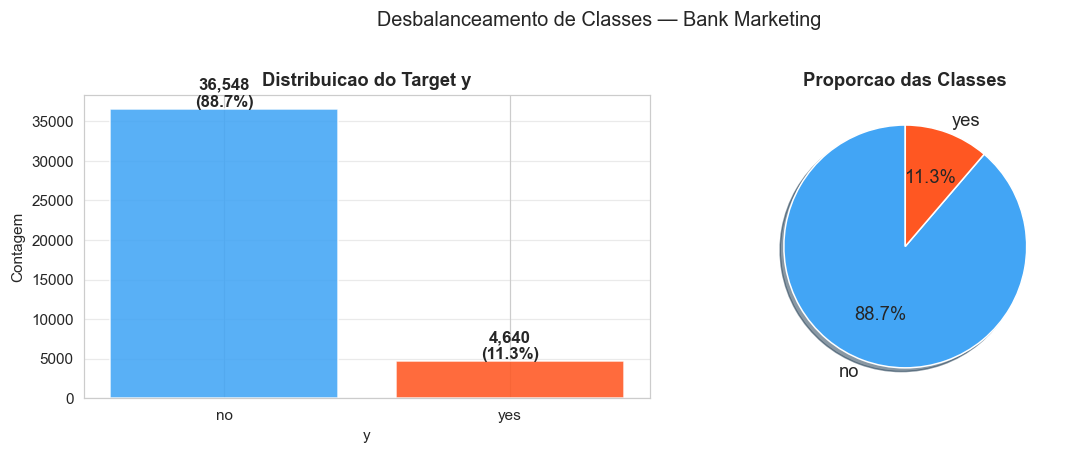

Implicacoes do desbalanceamento:
  - Acuracia nao e suficiente como metrica!
  - Modelo que preve sempre 'nao' teria 88.7% de acuracia
  - Estrategias adotadas neste notebook:
    -> class_weight='balanced' nos algoritmos que suportam
    -> Metrica principal: AUC-PR (Precision-Recall)
    -> Tambem reportamos: F1, AUC-ROC, Recall da classe positiva


In [4]:
# ─── Análise do Desbalanceamento de Classes ───────────────────────────────────
contagem = y_raw.value_counts()
cores    = ["#42A5F5", "#FF5722"]

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

# Barras
axes[0].bar(contagem.index, contagem.values, color=cores, alpha=0.88, edgecolor="white")
for i, (lbl, cnt) in enumerate(zip(contagem.index, contagem.values)):
    axes[0].text(i, cnt + 300, f"{cnt:,}\n({cnt/len(y_raw)*100:.1f}%)",
                 ha="center", fontsize=11, fontweight="bold")
axes[0].set_title("Distribuicao do Target y", fontsize=12, fontweight="bold")
axes[0].set_ylabel("Contagem"); axes[0].set_xlabel("y")
axes[0].grid(axis="y", alpha=0.4)

# Pizza
axes[1].pie(contagem.values, labels=contagem.index, colors=cores,
            autopct="%1.1f%%", startangle=90, shadow=True,
            textprops={"fontsize": 12})
axes[1].set_title("Proporcao das Classes", fontsize=12, fontweight="bold")

plt.suptitle("Desbalanceamento de Classes — Bank Marketing", fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig("fig_class_balance.png", dpi=150, bbox_inches="tight")
plt.show(); plt.close()

print("Implicacoes do desbalanceamento:")
print("  - Acuracia nao e suficiente como metrica!")
print("  - Modelo que preve sempre 'nao' teria 88.7% de acuracia")
print("  - Estrategias adotadas neste notebook:")
print("    -> class_weight='balanced' nos algoritmos que suportam")
print("    -> Metrica principal: AUC-PR (Precision-Recall)")
print("    -> Tambem reportamos: F1, AUC-ROC, Recall da classe positiva")

---
# 2. 📊 Métricas de Avaliação

## Matriz de Confusão

Base de todas as métricas. Para classificação binária:

|  | **Previsto: 0 (Não)** | **Previsto: 1 (Sim)** |
|---|---|---|
| **Real: 0 (Não)** | **TN** — Verdadeiro Negativo | **FP** — Falso Positivo (erro tipo I) |
| **Real: 1 (Sim)** | **FN** — Falso Negativo (erro tipo II) | **TP** — Verdadeiro Positivo |

No contexto do Bank Marketing:
- **FN** = cliente que assinaria, mas não foi contactado → **custo: receita perdida**
- **FP** = cliente contactado desnecessariamente → **custo: operacional do call center**

## As Métricas

| Métrica | Fórmula | Significado |
|---|---|---|
| **Acurácia** | (TP+TN) / Total | % de previsões corretas — **enganosa** em dados desbalanceados |
| **Precisão** | TP / (TP+FP) | Dos que previmos como "sim", quantos realmente são? |
| **Recall (Sensibilidade)** | TP / (TP+FN) | Dos que realmente são "sim", quantos detectamos? |
| **F1-Score** | 2 × P×R / (P+R) | Média harmônica entre Precisão e Recall |
| **AUC-ROC** | Área sob a Curva ROC | Capacidade de separar classes em diferentes thresholds |
| **AUC-PR** | Área sob a Curva P-R | **Mais sensível ao desbalanceamento** — métrica principal aqui |

## Curva ROC vs Curva Precision-Recall

**Curva ROC** plota TPR (Recall) vs FPR para todos os thresholds.
- Insensível ao desbalanceamento — um modelo ruim pode ter AUC-ROC alto com classes desbalanceadas.

**Curva Precision-Recall** plota Precisão vs Recall.
- **Mais informativa em datasets desbalanceados** — o baseline é a prevalência da classe positiva (11,3%).
- Um modelo sem informação teria AUC-PR ≈ 0,113.

> 🎯 **Regra prática para este dataset:** priorize **AUC-PR** e **Recall da classe positiva**.
> Um banco prefere ligar para alguns clientes errados (↑ FP) a perder clientes reais (↓ FN).

In [5]:
# ─── Armazenamento Global de Resultados ───────────────────────────────────────
results_table = {}   # nome -> dict de metricas
roc_curves    = {}   # nome -> (fpr, tpr, auc_val)
pr_curves     = {}   # nome -> (prec, rec, ap_val)

# ─── Sub-amostra para SVM (evitar timeout) ───────────────────────────────────
N_SVM = 10_000
X_train_svm, y_train_svm = resample(
    X_train, y_train, n_samples=N_SVM, stratify=y_train, random_state=42
)
print(f"Amostra SVM: {X_train_svm.shape} | Classe +: {y_train_svm.mean()*100:.1f}%")

# ─── Funcao de Avaliacao e Visualizacao ───────────────────────────────────────
def avaliar(clf, clf_name, use_svm_sample=False):
    X_tr = X_train_svm if use_svm_sample else X_train
    y_tr = y_train_svm if use_svm_sample else y_train

    t0  = time.time()
    clf.fit(X_tr, y_tr)
    t_fit = round(time.time() - t0, 2)

    y_pred = clf.predict(X_test)
    y_prob = None
    if hasattr(clf, "predict_proba"):
        y_prob = clf.predict_proba(X_test)[:, 1]
    elif hasattr(clf, "decision_function"):
        sc     = clf.decision_function(X_test)
        y_prob = (sc - sc.min()) / (sc.max() - sc.min() + 1e-9)

    acc  = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, zero_division=0)
    rec  = recall_score(y_test, y_pred, zero_division=0)
    f1   = f1_score(y_test, y_pred, zero_division=0)

    fpr_a = tpr_a = roc_v = None
    prec_c = rec_c = ap_v = None

    if y_prob is not None:
        fpr_a, tpr_a, _ = roc_curve(y_test, y_prob)
        roc_v           = auc(fpr_a, tpr_a)
        prec_c, rec_c, _ = precision_recall_curve(y_test, y_prob)
        ap_v            = average_precision_score(y_test, y_prob)
        roc_curves[clf_name] = (fpr_a, tpr_a, roc_v)
        pr_curves[clf_name]  = (prec_c, rec_c, ap_v)

    results_table[clf_name] = {
        "Acuracia":    round(acc,  4),
        "Precisao(+)": round(prec, 4),
        "Recall(+)":   round(rec,  4),
        "F1(+)":       round(f1,   4),
        "AUC-ROC":     round(roc_v,  4) if roc_v  is not None else None,
        "AUC-PR":      round(ap_v,   4) if ap_v   is not None else None,
        "Tempo(s)":    t_fit,
    }

    # ── Painel 2x2 ──────────────────────────────────────────────────────────────
    fig, axes = plt.subplots(2, 2, figsize=(13, 9))
    fig.suptitle(f"Resultados: {clf_name}", fontsize=14, fontweight="bold")

    # [0,0] Matriz de Confusao
    ax = axes[0, 0]
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax,
                xticklabels=["Nao (0)", "Sim (1)"],
                yticklabels=["Nao (0)", "Sim (1)"])
    ax.set_title("Matriz de Confusao", fontweight="bold")
    ax.set_ylabel("Real"); ax.set_xlabel("Previsto")
    ax.text(0.5, -0.15,
            f"TN={cm[0,0]:,}  FP={cm[0,1]:,}  FN={cm[1,0]:,}  TP={cm[1,1]:,}",
            ha="center", transform=ax.transAxes, fontsize=9, color="gray")

    # [0,1] Curva ROC
    ax = axes[0, 1]
    if fpr_a is not None:
        ax.plot(fpr_a, tpr_a, color="darkorange", lw=2.5,
                label=f"AUC-ROC = {roc_v:.3f}")
        ax.plot([0,1],[0,1], "k--", lw=1.5, label="Baseline (random)")
        ax.fill_between(fpr_a, tpr_a, alpha=0.12, color="darkorange")
        ax.set_xlabel("Taxa de Falsos Positivos (FPR)")
        ax.set_ylabel("Taxa de Verdadeiros Positivos (TPR)")
        ax.legend(fontsize=10)
    else:
        ax.text(0.5, 0.5, "Score nao\ndisponivel", ha="center",
                va="center", fontsize=12)
    ax.set_title("Curva ROC", fontweight="bold")

    # [1,0] Curva Precision-Recall
    ax = axes[1, 0]
    if prec_c is not None:
        bl = y_test.mean()
        ax.plot(rec_c, prec_c, color="navy", lw=2.5, label=f"AUC-PR = {ap_v:.3f}")
        ax.axhline(bl, color="gray", ls="--", lw=1.5, label=f"Baseline = {bl:.3f}")
        ax.fill_between(rec_c, prec_c, alpha=0.12, color="navy")
        ax.set_xlabel("Recall"); ax.set_ylabel("Precisao")
        ax.legend(fontsize=10)
    else:
        ax.text(0.5, 0.5, "Score nao\ndisponivel", ha="center",
                va="center", fontsize=12)
    ax.set_title("Curva Precision-Recall", fontweight="bold")

    # [1,1] Feature Importance / Coeficientes / Report
    ax  = axes[1, 1]
    TOP = 12
    if hasattr(clf, "feature_importances_"):
        imp = clf.feature_importances_
        idx = np.argsort(imp)[-TOP:]
        ax.barh(range(TOP), imp[idx], color="steelblue", alpha=0.85)
        ax.set_yticks(range(TOP))
        ax.set_yticklabels([feature_names[i] for i in idx], fontsize=8)
        ax.set_xlabel("Importancia (Gini)")
        ax.set_title(f"Top {TOP} Features", fontweight="bold")
    elif hasattr(clf, "coef_"):
        coef = clf.coef_.ravel()
        idx  = np.argsort(np.abs(coef))[-TOP:]
        cols = ["#e53935" if coef[i] > 0 else "#42A5F5" for i in idx]
        ax.barh(range(TOP), coef[idx], color=cols, alpha=0.85)
        ax.set_yticks(range(TOP))
        ax.set_yticklabels([feature_names[i] for i in idx], fontsize=8)
        ax.axvline(0, color="black", lw=0.8)
        ax.set_xlabel("Coeficiente")
        ax.set_title(f"Top {TOP} Coeficientes", fontweight="bold")
        ax.text(0.99, 0.01, "Vermelho=positivo | Azul=negativo",
                transform=ax.transAxes, ha="right", fontsize=7, color="gray")
    else:
        rep = classification_report(y_test, y_pred, target_names=["Nao", "Sim"])
        ax.text(0.04, 0.97, rep, transform=ax.transAxes, fontsize=8.5,
                verticalalignment="top", family="monospace")
        ax.axis("off")
        ax.set_title("Relatorio de Classificacao", fontweight="bold")

    plt.tight_layout()
    fname = clf_name.lower().replace(" ", "_").replace("-", "_")
    plt.savefig(f"fig_clf_{fname}.png", dpi=150, bbox_inches="tight")
    plt.show(); plt.close(fig)

    # Relatorio textual
    print(f"\n{'='*60}")
    print(f"RELATORIO — {clf_name}  |  Treino: {t_fit}s")
    print("="*60)
    print(classification_report(y_test, y_pred, target_names=["Nao (0)", "Sim (1)"]))
    if roc_v is not None: print(f"AUC-ROC : {roc_v:.4f}")
    if ap_v  is not None: print(f"AUC-PR  : {ap_v:.4f}")
    return clf

print("Funcao avaliar() definida! Pronto para treinar os modelos.")

Amostra SVM: (10000, 19) | Classe +: 11.3%
Funcao avaliar() definida! Pronto para treinar os modelos.


---
# 3. 📊 Regressão Logística

## Teoria

A **Regressão Logística** é o algoritmo de classificação mais fundamental. Apesar do nome, é
usado para **classificação** (não regressão). O modelo estima a probabilidade de uma observação
pertencer à classe positiva aplicando a **função sigmoide** sobre uma combinação linear das features:

```
P(y=1 | X) = σ(z) = 1 / (1 + e^(-z))
onde  z = β₀ + β₁x₁ + β₂x₂ + ... + βₙxₙ
```

Os coeficientes β são estimados maximizando a **log-verossimilhança** (equivalentemente,
minimizando a *Binary Cross-Entropy Loss*). O modelo usa regularização L2 por padrão,
penalizando coeficientes muito grandes para evitar overfitting.

## Vantagens
- **Interpretável:** os coeficientes revelam direção e magnitude do efeito de cada feature
- Rápido para treinar mesmo em grandes datasets
- Produz **probabilidades calibradas**
- Excelente **baseline** — frequentemente competitivo com modelos complexos
- Suporta regularização L1 (esparsidade) e L2 (estabilidade)

## Desvantagens
- Assume relação **linear** entre features e log-odds
- Não captura interações entre variáveis sem engenharia de features
- Desempenho limitado quando fronteiras de decisão são fortemente não-lineares

## Parâmetros Principais

| Parâmetro | Descrição | Valor usado |
|---|---|---|
| `C` | Inverso da regularização — maior C = menos regularização | 1.0 |
| `penalty` | Tipo de regularização: `l2`, `l1`, `elasticnet` | `l2` |
| `class_weight` | Pesos por classe — compensa desbalanceamento | `'balanced'` |
| `max_iter` | Máximo de iterações do solver | 1000 |
| `solver` | Algoritmo de otimização | `lbfgs` |

> 💡 **No Bank Marketing:** Os coeficientes da Regressão Logística revelarão diretamente
> quais variáveis macroeconômicas (`euribor3m`, `emp.var.rate`) e comportamentais
> (`poutcome`, `previous`) mais influenciam a probabilidade de adesão.

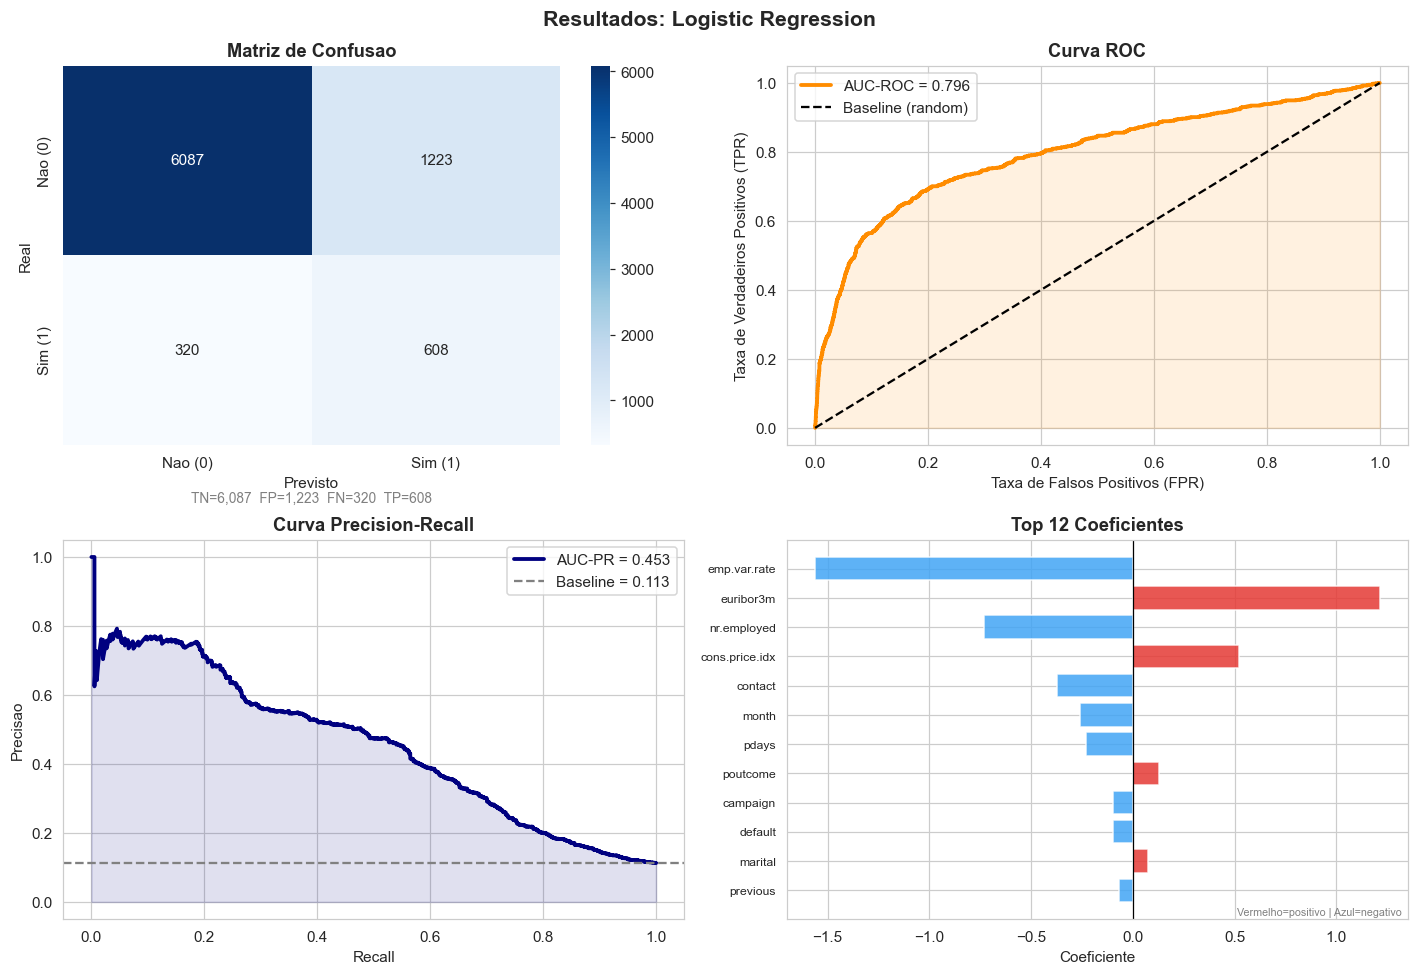


RELATORIO — Logistic Regression  |  Treino: 0.08s
              precision    recall  f1-score   support

     Nao (0)       0.95      0.83      0.89      7310
     Sim (1)       0.33      0.66      0.44       928

    accuracy                           0.81      8238
   macro avg       0.64      0.74      0.66      8238
weighted avg       0.88      0.81      0.84      8238

AUC-ROC : 0.7959
AUC-PR  : 0.4530


In [6]:
# ─── Regressão Logística ──────────────────────────────────────────────────────
clf_lr = LogisticRegression(
    C=1.0,
    penalty="l2",
    class_weight="balanced",
    max_iter=1000,
    solver="lbfgs",
    random_state=42,
)
clf_lr = avaliar(clf_lr, "Logistic Regression")

---
# 4. 🔵 K-Nearest Neighbors (KNN)

## Teoria

O KNN é um algoritmo **baseado em instâncias** (também chamado de lazy learning): não
constrói um modelo interno durante o treinamento — simplesmente **memoriza** todos os dados.
Para classificar uma nova observação, encontra os K vizinhos mais próximos no espaço de
features e retorna a **classe majoritária** entre eles.

A distância mais comum é a **Euclidiana**, mas também se usam Minkowski, Manhattan, etc.:

```
d(x, xᵢ) = √(Σⱼ (xⱼ - xᵢⱼ)²)    [Distância Euclidiana]
```

A escolha de K é fundamental:
- **K pequeno (1-3):** fronteira de decisão muito irregular → alto risco de overfitting
- **K grande (20+):** fronteira suavizada → pode subajustar (underfitting)

## Vantagens
- Simples de entender e implementar
- Não faz suposições sobre a distribuição dos dados
- Naturalmente multiclasse

## Desvantagens
- Lento na predição: calcula distâncias para todos os N pontos de treino (O(n×d))
- Muito sensível à **escala das features** — padronização obrigatória
- Sensível a features irrelevantes (curse of dimensionality)
- Não suporta `class_weight` — dados desbalanceados são um desafio

## Parâmetros Principais

| Parâmetro | Descrição | Valor usado |
|---|---|---|
| `n_neighbors` | Número de vizinhos K | 7 |
| `weights` | `uniform` = todos iguais; `distance` = vizinhos próximos têm mais peso | `distance` |
| `metric` | Métrica de distância | `minkowski` (≡ Euclidiana com p=2) |

> 💡 **No Bank Marketing:** KNN pode ter dificuldade com o desbalanceamento (sem class_weight).
> Usar `weights='distance'` atenua o problema parcialmente.

Testando valores de K...
  K= 3 -> F1(+)=0.3539
  K= 7 -> F1(+)=0.3696
  K=15 -> F1(+)=0.3646
  K=25 -> F1(+)=0.3456

Usando K=7 (melhor trade-off visualizado acima)...


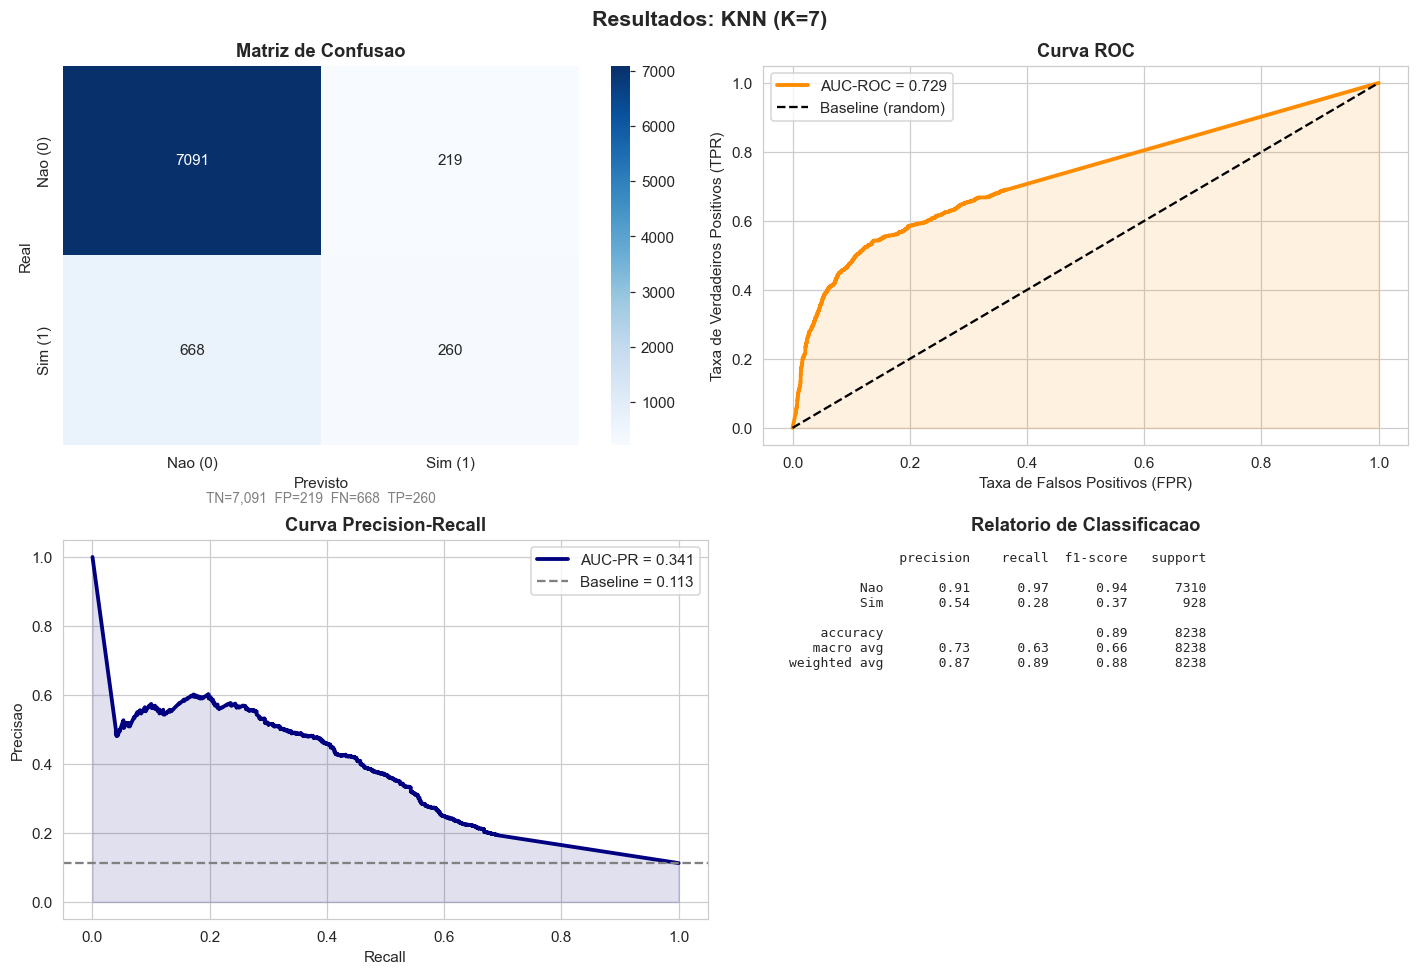


RELATORIO — KNN (K=7)  |  Treino: 0.01s
              precision    recall  f1-score   support

     Nao (0)       0.91      0.97      0.94      7310
     Sim (1)       0.54      0.28      0.37       928

    accuracy                           0.89      8238
   macro avg       0.73      0.63      0.66      8238
weighted avg       0.87      0.89      0.88      8238

AUC-ROC : 0.7287
AUC-PR  : 0.3415


In [7]:
# ─── K-Nearest Neighbors ─────────────────────────────────────────────────────
# Testamos K=3, K=7, K=15 brevemente antes de escolher
print("Testando valores de K...")
for k in [3, 7, 15, 25]:
    knn_test = KNeighborsClassifier(n_neighbors=k, weights="distance", n_jobs=-1)
    knn_test.fit(X_train, y_train)
    p = knn_test.predict(X_test)
    f1 = f1_score(y_test, p, zero_division=0)
    print(f"  K={k:2d} -> F1(+)={f1:.4f}")

print("\nUsando K=7 (melhor trade-off visualizado acima)...")
clf_knn = KNeighborsClassifier(n_neighbors=7, weights="distance", n_jobs=-1)
clf_knn = avaliar(clf_knn, "KNN (K=7)")

---
# 5. ⚡ SVM Linear — Máquina de Vetores de Suporte Linear

## Teoria

Uma **SVM** constrói um hiperplano que **maximiza a margem** entre as duas classes. O
hiperplano ótimo é aquele com a maior distância dos pontos mais próximos de cada classe
— chamados **vetores de suporte**.

No caso linear (2D):
```
f(x) = w₁x₁ + w₂x₂ + b = 0     [hiperplano de separação]
Margem = 2 / ||w||               [a maximizar]
```

Para dados não linearmente separáveis, usa-se o parâmetro de regularização **C**:
- **C alto:** penaliza mais os erros → margem menor, mais complexo → risco de overfitting
- **C baixo:** aceita mais erros → margem maior, mais simples → risco de underfitting

## Vantagens
- Eficaz em espaços de alta dimensão
- Robusto a outliers (depende apenas dos vetores de suporte)
- Oferece coeficientes interpretáveis (no caso linear)

## Desvantagens
- Não fornece probabilidades diretamente (requer `probability=True`, que é lento)
- Sensível à escala das features — padronização obrigatória
- Treinamento O(n²) a O(n³) — **lento em datasets grandes**
  → Neste notebook usamos uma sub-amostra de 10.000 registros para SVM

## Parâmetros Principais

| Parâmetro | Descrição | Valor usado |
|---|---|---|
| `kernel` | Tipo de kernel: `linear`, `rbf`, `poly` | `linear` |
| `C` | Parâmetro de regularização | 1.0 |
| `class_weight` | Peso por classe | `'balanced'` |
| `probability` | Habilita `predict_proba` (mais lento) | `True` |

> ⚠️ **Atenção:** Usando amostra de 10.000 registros para SVM (motivo: complexidade O(n²)).
> Os resultados são representativos mas podem diferir levemente do treino completo.

Treino com 10,000 amostras (sub-amostra estratificada)...


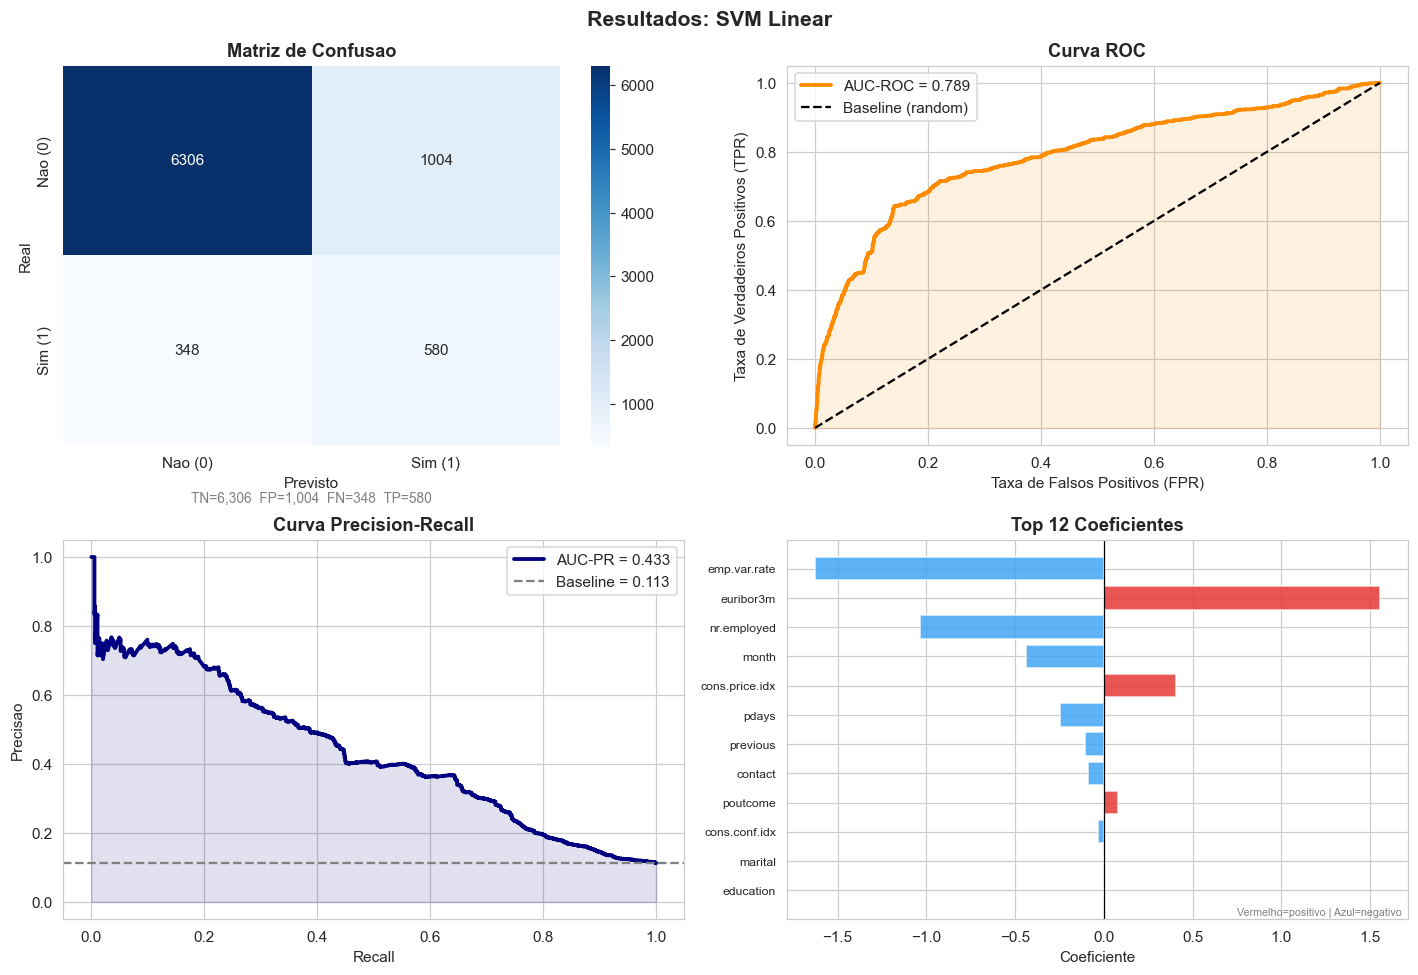


RELATORIO — SVM Linear  |  Treino: 224.1s
              precision    recall  f1-score   support

     Nao (0)       0.95      0.86      0.90      7310
     Sim (1)       0.37      0.62      0.46       928

    accuracy                           0.84      8238
   macro avg       0.66      0.74      0.68      8238
weighted avg       0.88      0.84      0.85      8238

AUC-ROC : 0.7893
AUC-PR  : 0.4334


In [8]:
# ─── SVM Linear ──────────────────────────────────────────────────────────────
# ⚠️ Usando sub-amostra de 10k registros (SVM e O(n^2) a O(n^3))
print(f"Treino com {X_train_svm.shape[0]:,} amostras (sub-amostra estratificada)...")

clf_svm_lin = SVC(
    kernel="linear",
    C=1.0,
    class_weight="balanced",
    probability=True,
    random_state=42,
)
clf_svm_lin = avaliar(clf_svm_lin, "SVM Linear", use_svm_sample=True)

---
# 6. 🌀 SVM RBF — Kernel de Função de Base Radial

## Teoria

O **kernel RBF (Radial Basis Function)** transforma implicitamente os dados para um espaço
de dimensão infinita, permitindo separar classes que não são linearmente separáveis:

```
K(xᵢ, xⱼ) = exp(-γ ||xᵢ - xⱼ||²)
```

O parâmetro **γ (gamma)** controla o "raio de influência" de cada ponto de treinamento:
- **γ alto:** cada ponto influencia apenas seus vizinhos muito próximos → fronteira irregular → overfitting
- **γ baixo:** cada ponto tem influência ampla → fronteira suave → possível underfitting

Junto com **C**, forma um par de hiperparâmetros críticos. A busca por grid search
(`GridSearchCV`) é recomendada para otimizá-los.

## Vantagens
- Captura fronteiras de decisão não-lineares complexas
- Versátil: funciona bem em muitos tipos de dados

## Desvantagens
- **Não interpretável** — sem feature importance ou coeficientes diretos
- Treinamento ainda mais lento que SVM linear para datasets grandes
- Requer escolha cuidadosa de C e γ

## Parâmetros Principais

| Parâmetro | Descrição | Valor usado |
|---|---|---|
| `kernel` | Tipo de kernel | `rbf` |
| `C` | Regularização | 1.0 |
| `gamma` | Escala do RBF | `scale` (= 1/(n_features × Var(X))) |
| `class_weight` | Compensação do desbalanceamento | `'balanced'` |

> 💡 **SVM Linear vs RBF:** Se o linear já performa bem, o RBF raramente compensa o
> custo computacional adicional. Compare os resultados das duas células para decidir.

Treino com 10,000 amostras (sub-amostra estratificada)...


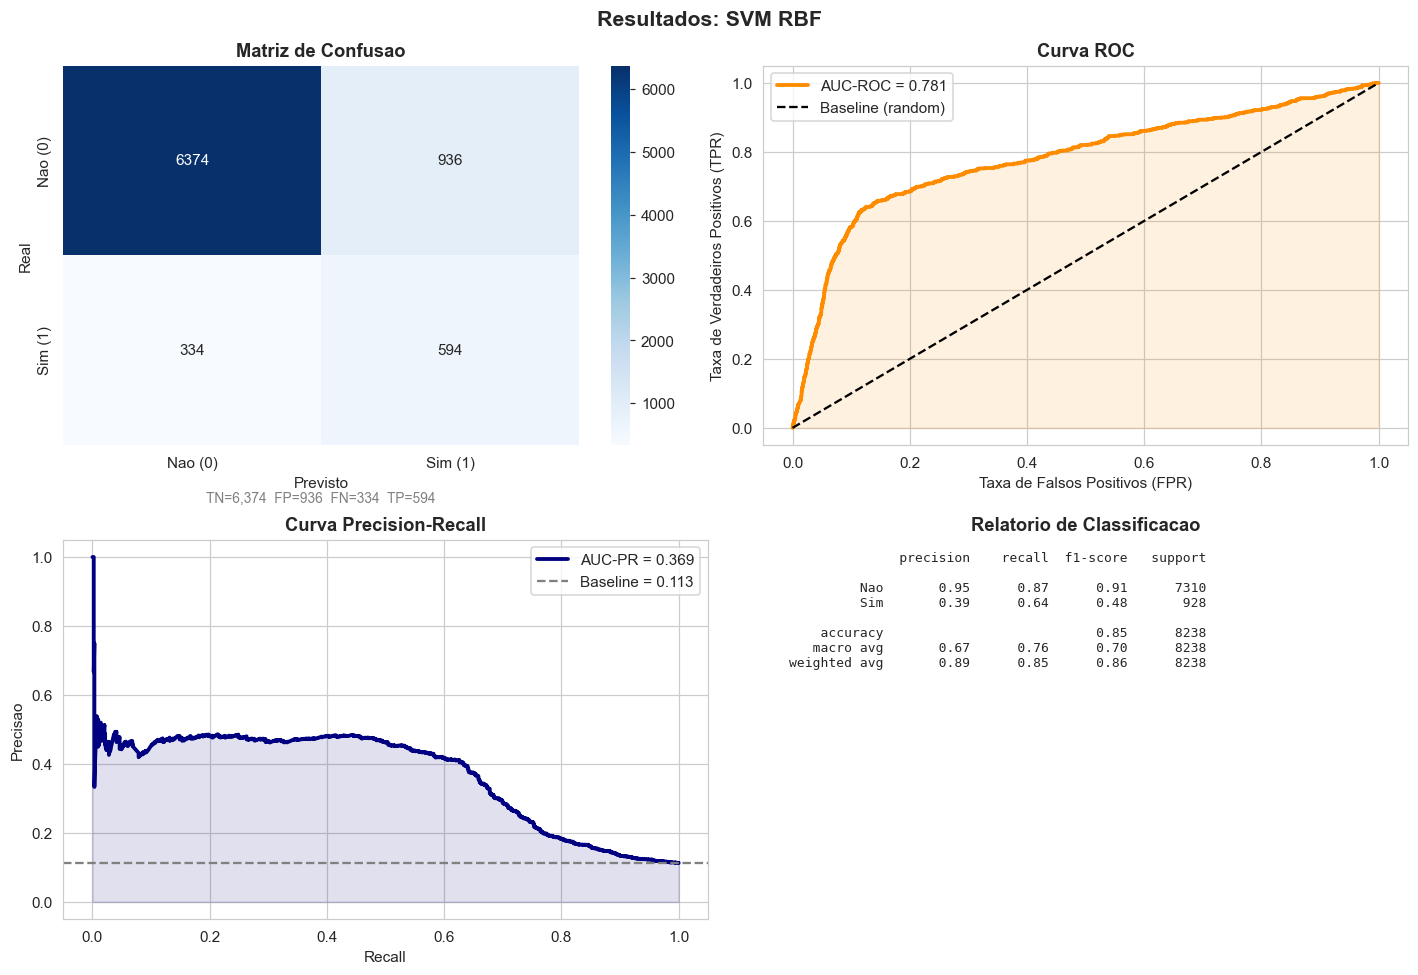


RELATORIO — SVM RBF  |  Treino: 39.92s
              precision    recall  f1-score   support

     Nao (0)       0.95      0.87      0.91      7310
     Sim (1)       0.39      0.64      0.48       928

    accuracy                           0.85      8238
   macro avg       0.67      0.76      0.70      8238
weighted avg       0.89      0.85      0.86      8238

AUC-ROC : 0.7812
AUC-PR  : 0.3691


In [9]:
# ─── SVM RBF ─────────────────────────────────────────────────────────────────
print(f"Treino com {X_train_svm.shape[0]:,} amostras (sub-amostra estratificada)...")

clf_svm_rbf = SVC(
    kernel="rbf",
    C=1.0,
    gamma="scale",
    class_weight="balanced",
    probability=True,
    random_state=42,
)
clf_svm_rbf = avaliar(clf_svm_rbf, "SVM RBF", use_svm_sample=True)

---
# 7. 🌳 Árvore de Decisão

## Teoria

As **Árvores de Decisão** aprendem regras **if-then-else** a partir dos dados. Em cada nó,
o algoritmo seleciona a feature e o limiar que **melhor separa as classes** segundo algum
critério de impureza.

O critério mais comum é o **Índice de Gini**:
```
Gini(t) = 1 - Σₖ p(k|t)²
```
onde p(k|t) é a proporção da classe k no nó t. Um nó puro tem Gini = 0.

O algoritmo expande a árvore de forma **recursiva e gulosa** (greedy), dividindo cada nó
até atingir os critérios de parada (profundidade máxima, mínimo de amostras, etc.).

## Vantagens
- **Extremamente interpretável** — a árvore pode ser visualizada e explicada em linguagem natural
- Não requer padronização das features
- Captura interações entre variáveis automaticamente
- Funciona com dados numéricos e categóricos

## Desvantagens
- Alta variância: pequenas mudanças nos dados → árvore completamente diferente
- Propenso a **overfitting** sem regularização (poda, profundidade máxima)
- Performance inferior a métodos ensemble

## Parâmetros Principais

| Parâmetro | Descrição | Valor usado |
|---|---|---|
| `max_depth` | Profundidade máxima da árvore | 8 |
| `min_samples_leaf` | Mínimo de amostras por folha | 20 |
| `criterion` | Critério de divisão | `gini` |
| `class_weight` | Compensação do desbalanceamento | `'balanced'` |

> 💡 **No Bank Marketing:** A visualização da árvore (com `plot_tree`) permite ao aluno
> ver explicitamente quais variáveis e limiares o modelo usa para tomar decisões.

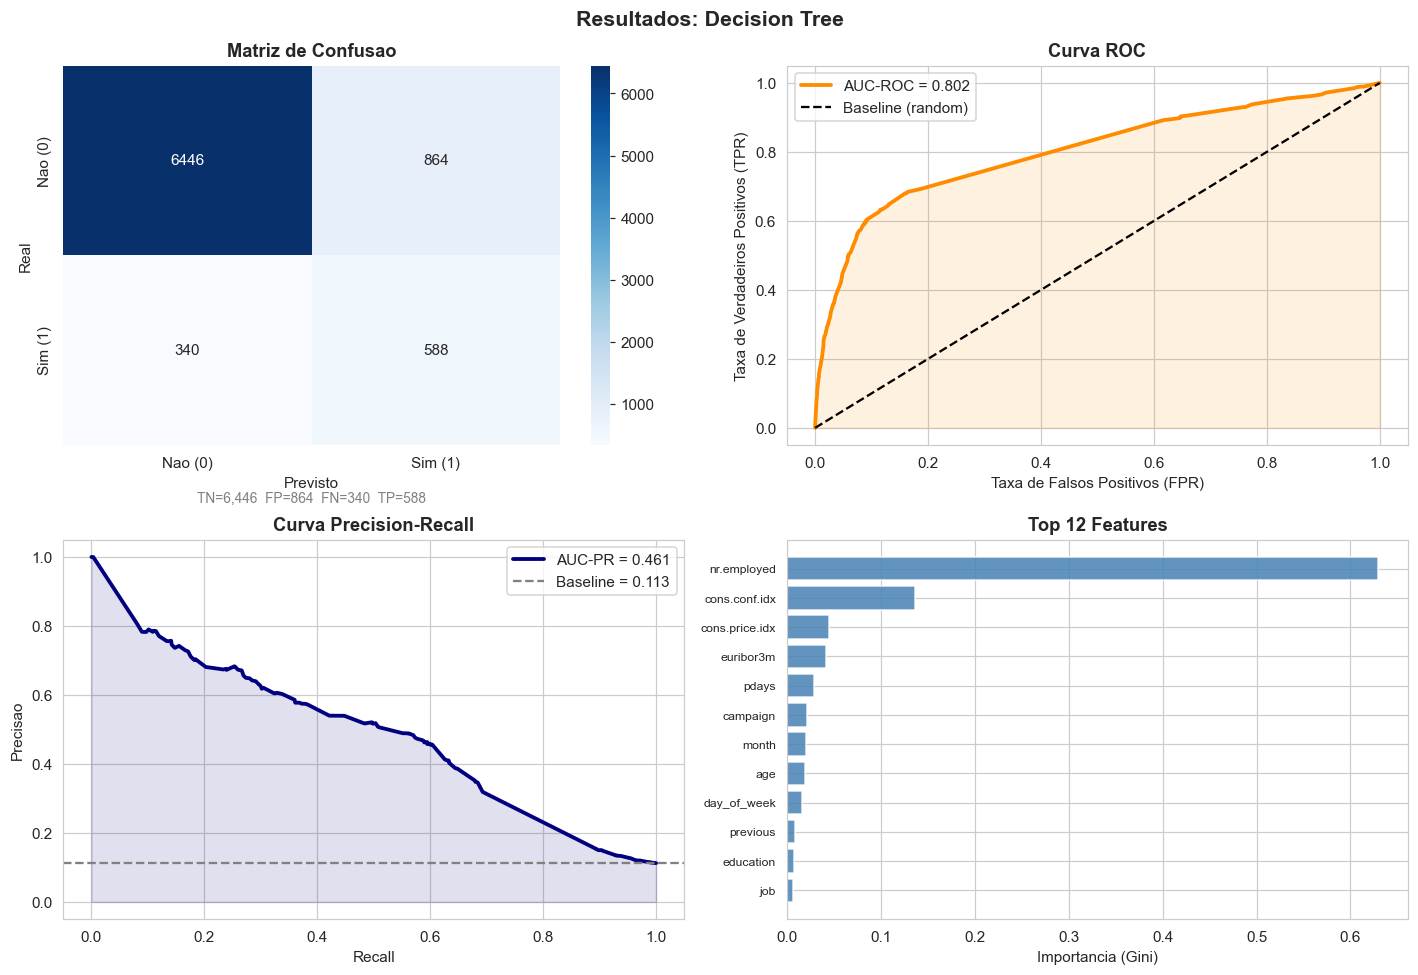


RELATORIO — Decision Tree  |  Treino: 0.14s
              precision    recall  f1-score   support

     Nao (0)       0.95      0.88      0.91      7310
     Sim (1)       0.40      0.63      0.49       928

    accuracy                           0.85      8238
   macro avg       0.68      0.76      0.70      8238
weighted avg       0.89      0.85      0.87      8238

AUC-ROC : 0.8023
AUC-PR  : 0.4605

Visualizacao dos 3 primeiros niveis da arvore de decisao:


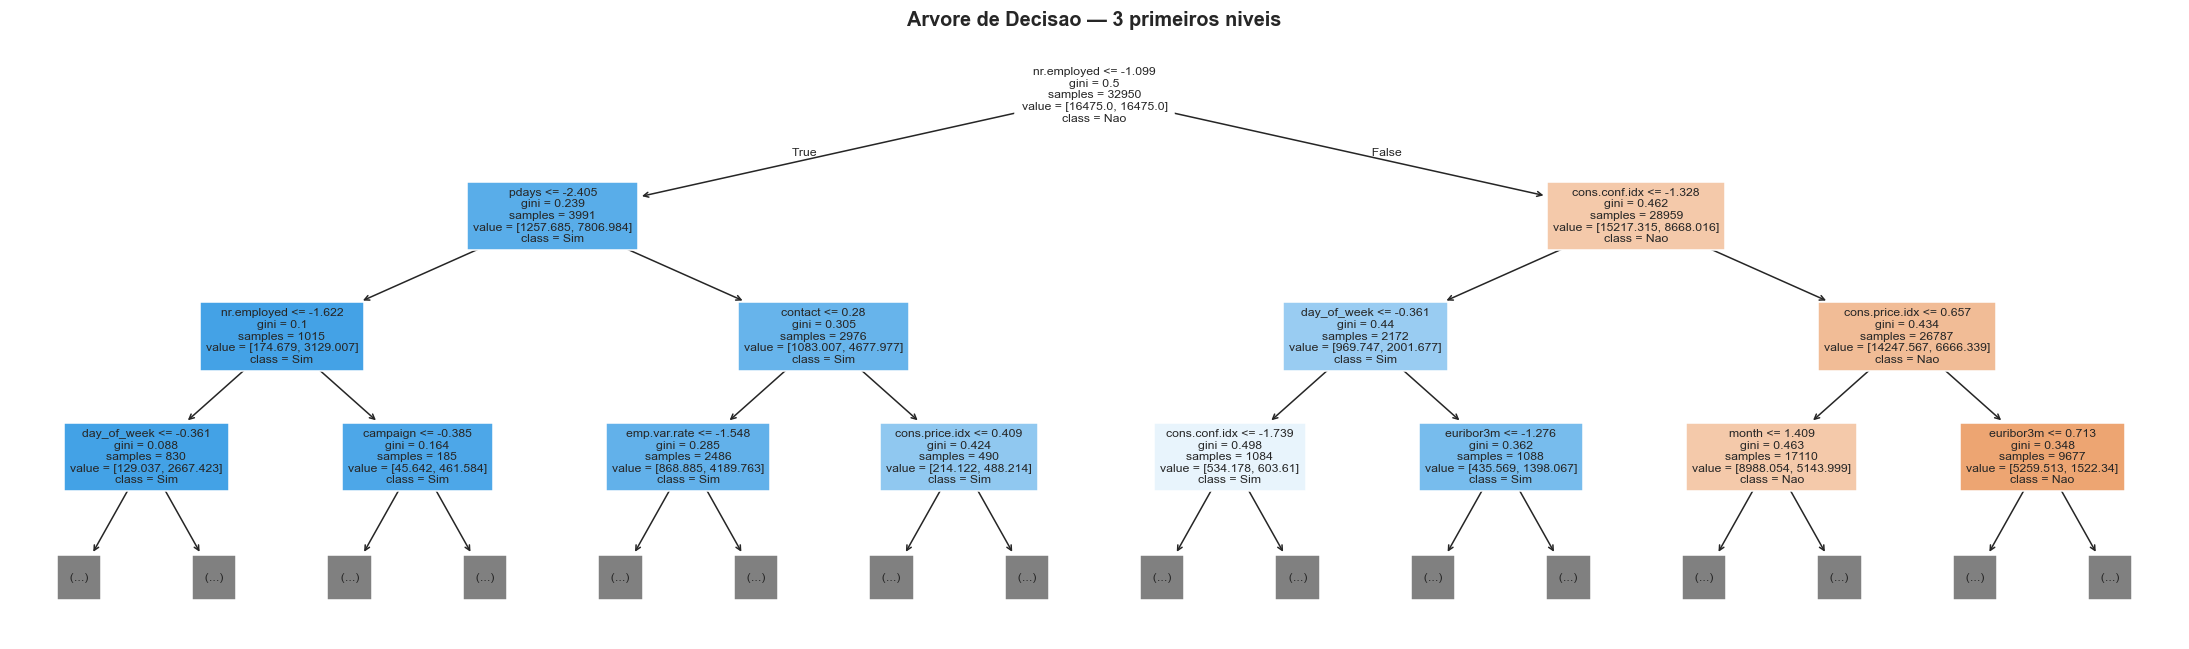

Profundidade real da arvore: 8
Numero de folhas: 137


In [10]:
# ─── Árvore de Decisão ────────────────────────────────────────────────────────
clf_dt = DecisionTreeClassifier(
    max_depth=8,
    min_samples_leaf=20,
    criterion="gini",
    class_weight="balanced",
    random_state=42,
)
clf_dt = avaliar(clf_dt, "Decision Tree")

# Visualizar os 3 primeiros níveis da árvore
print("\nVisualizacao dos 3 primeiros niveis da arvore de decisao:")
fig_tree, ax_tree = plt.subplots(figsize=(20, 6))
plot_tree(clf_dt, max_depth=3,
          feature_names=feature_names,
          class_names=["Nao", "Sim"],
          filled=True, fontsize=8, ax=ax_tree,
          impurity=True, proportion=False)
ax_tree.set_title("Arvore de Decisao — 3 primeiros niveis", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("fig_decision_tree_structure.png", dpi=120, bbox_inches="tight")
plt.show(); plt.close(fig_tree)
print(f"Profundidade real da arvore: {clf_dt.get_depth()}")
print(f"Numero de folhas: {clf_dt.get_n_leaves()}")

---
# 8. 🌲🌲🌲 Random Forest

## Teoria

Random Forest é um método de **ensemble (Bagging)** que combina múltiplas Árvores de
Decisão para obter um modelo mais robusto e generalizável. Dois mecanismos de aleatoriedade
reduzem a variância:

1. **Bootstrap sampling:** cada árvore é treinada em uma amostra aleatória com reposição
   dos dados originais (~63,2% dos dados únicos por árvore).

2. **Feature subsampling:** em cada divisão, apenas um subconjunto aleatório de features
   é considerado — isso descorrelaciona as árvores entre si.

A **previsão final** é dada pelo **voto majoritário** das N árvores (classificação) ou pela
média (regressão). A **importância das features** é medida pela redução média de impureza
(Gini) causada por cada feature em todas as divisões de todas as árvores.

## Vantagens
- Muito robusto: reduz overfitting em relação à árvore simples
- **Feature importance** confiável e intuitiva
- Paralelizável (`n_jobs=-1`)
- Excelente performance out-of-the-box (poucos hiperparâmetros críticos)

## Desvantagens
- Menos interpretável que uma árvore simples ("black box")
- Mais lento e mais memória que uma árvore única
- Pode ser superado por boosting (XGBoost, LightGBM) em muitos casos

## Parâmetros Principais

| Parâmetro | Descrição | Valor usado |
|---|---|---|
| `n_estimators` | Número de árvores | 200 |
| `max_depth` | Profundidade máxima de cada árvore | 10 |
| `max_features` | Features por divisão | `sqrt` |
| `class_weight` | Compensação do desbalanceamento | `'balanced'` |
| `n_jobs` | Paralelismo | -1 (todos os cores) |

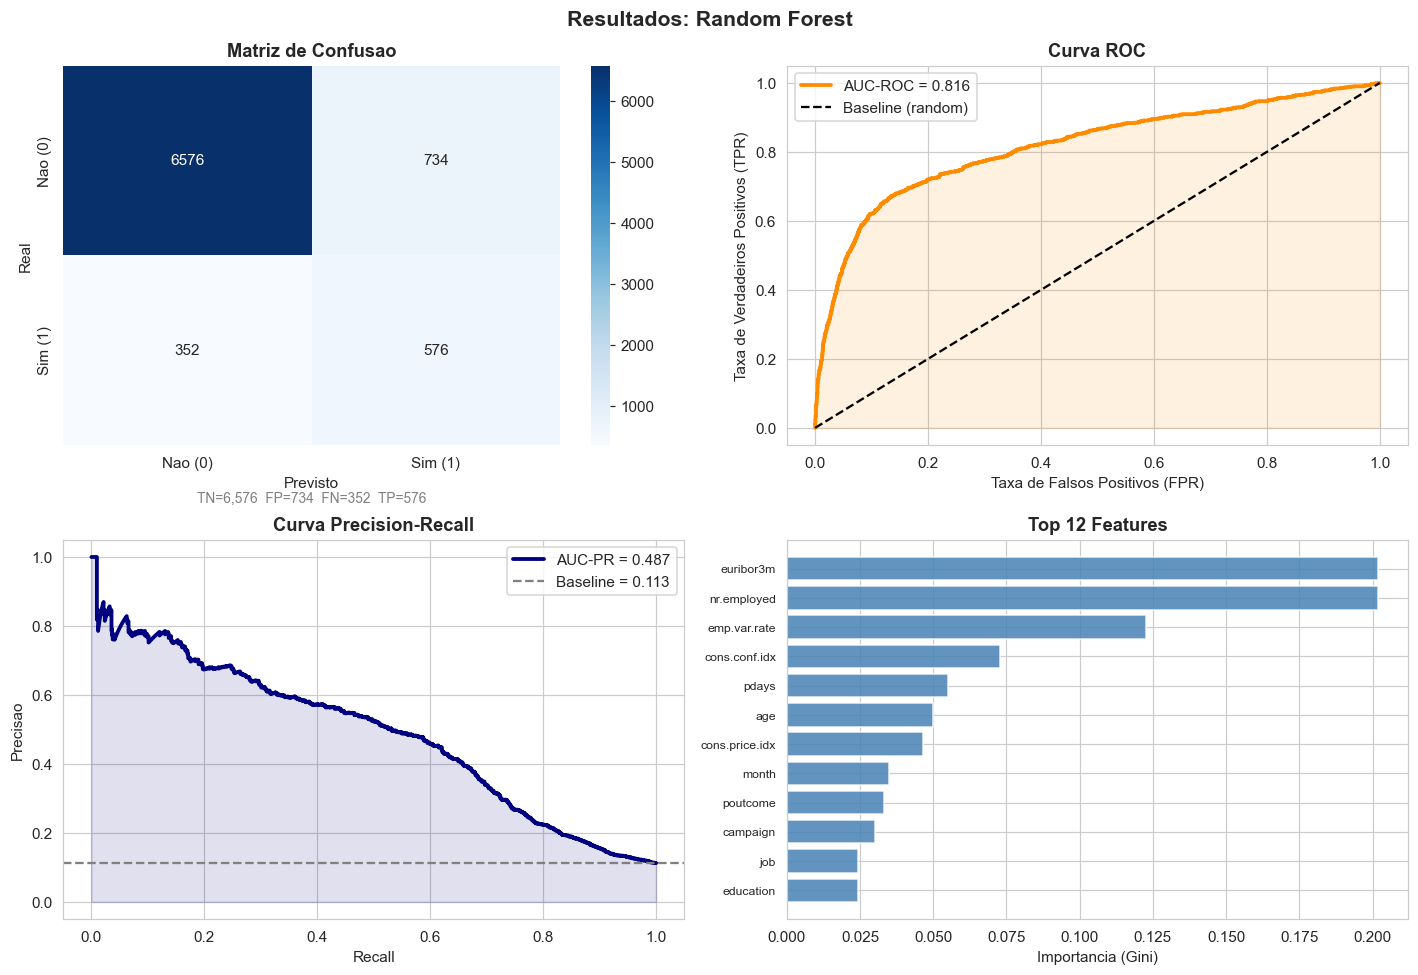


RELATORIO — Random Forest  |  Treino: 1.15s
              precision    recall  f1-score   support

     Nao (0)       0.95      0.90      0.92      7310
     Sim (1)       0.44      0.62      0.51       928

    accuracy                           0.87      8238
   macro avg       0.69      0.76      0.72      8238
weighted avg       0.89      0.87      0.88      8238

AUC-ROC : 0.8163
AUC-PR  : 0.4872


In [11]:
# ─── Random Forest ────────────────────────────────────────────────────────────
clf_rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    max_features="sqrt",
    class_weight="balanced",
    n_jobs=-1,
    random_state=42,
)
clf_rf = avaliar(clf_rf, "Random Forest")

---
# 9. 🧠 MLP — Multi-Layer Perceptron

## Teoria

O **MLP (Multi-Layer Perceptron)** é uma rede neural artificial com pelo menos uma camada
oculta entre a entrada e a saída. Cada neurônio aplica uma transformação não-linear
(função de ativação) sobre uma soma ponderada das entradas da camada anterior:

```
h⁽ˡ⁾ = σ(W⁽ˡ⁾ · h⁽ˡ⁻¹⁾ + b⁽ˡ⁾)
```

O MLP é treinado por **backpropagation** com **gradient descent**, minimizando a
Binary Cross-Entropy Loss. O processo envolve:

1. **Forward pass:** propagar a entrada pela rede e obter a predição
2. **Calcular o erro** (loss) entre predição e real
3. **Backward pass:** propagar o gradiente do erro de volta pela rede
4. **Atualizar os pesos** na direção do gradiente descendente

## Vantagens
- Aprende relações **não-lineares complexas** automaticamente
- Muito flexível: número de camadas e neurônios é configurável
- Pode aproximar qualquer função contínua (Teorema da Aproximação Universal)

## Desvantagens
- Muitos hiperparâmetros para ajustar (arquitetura, learning rate, regularização)
- Sensível à escala — padronização obrigatória
- Treinamento pode ser lento e instável (múltiplos mínimos locais)
- Interpretação difícil ("caixa preta")
- **Não possui `class_weight`** — usa amostragem estratificada como alternativa

## Parâmetros Principais

| Parâmetro | Descrição | Valor usado |
|---|---|---|
| `hidden_layer_sizes` | Arquitetura da rede | `(128, 64)` |
| `activation` | Função de ativação | `relu` |
| `alpha` | Regularização L2 | 0.001 |
| `learning_rate_init` | Taxa de aprendizado inicial | 0.001 |
| `max_iter` | Máximo de épocas | 300 |

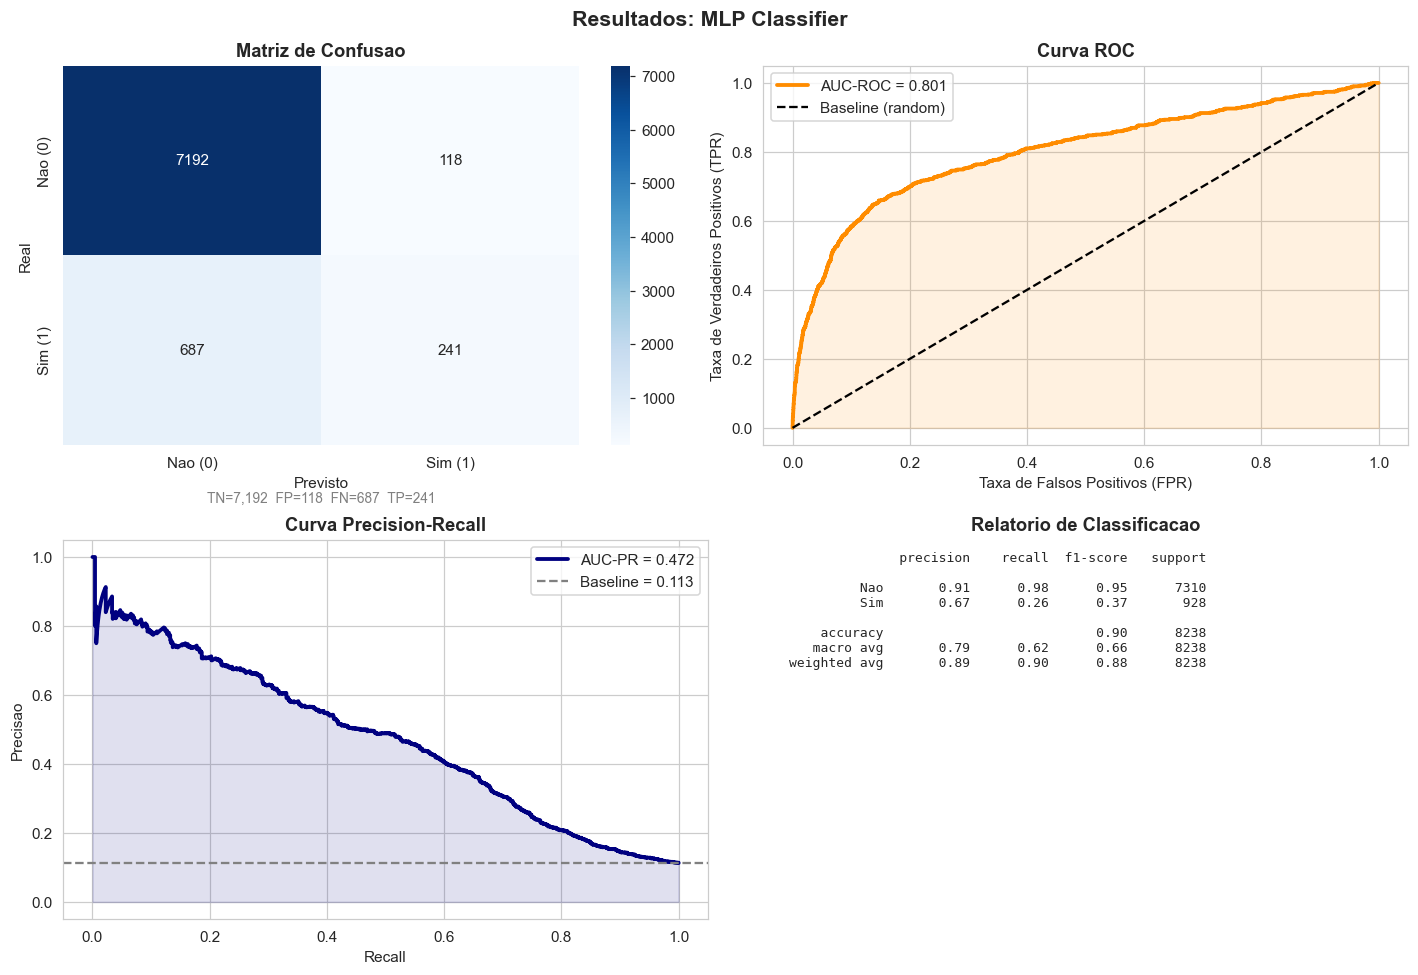


RELATORIO — MLP Classifier  |  Treino: 8.19s
              precision    recall  f1-score   support

     Nao (0)       0.91      0.98      0.95      7310
     Sim (1)       0.67      0.26      0.37       928

    accuracy                           0.90      8238
   macro avg       0.79      0.62      0.66      8238
weighted avg       0.89      0.90      0.88      8238

AUC-ROC : 0.8014
AUC-PR  : 0.4723


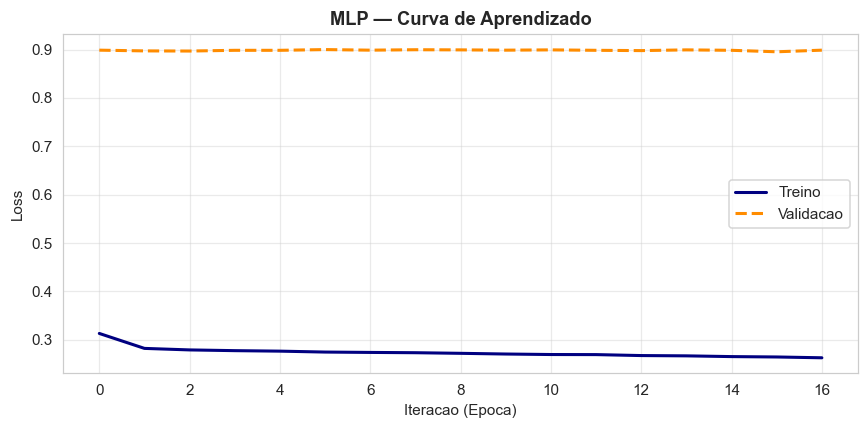

In [12]:
# ─── MLP Classifier ──────────────────────────────────────────────────────────
clf_mlp = MLPClassifier(
    hidden_layer_sizes=(128, 64),
    activation="relu",
    alpha=0.001,
    learning_rate_init=0.001,
    max_iter=300,
    early_stopping=True,
    validation_fraction=0.1,
    random_state=42,
)
clf_mlp = avaliar(clf_mlp, "MLP Classifier")

# Curva de loss (se disponivel)
if hasattr(clf_mlp, "loss_curve_"):
    fig_lc, ax_lc = plt.subplots(figsize=(8, 4))
    ax_lc.plot(clf_mlp.loss_curve_, color="navy", lw=2, label="Treino")
    if hasattr(clf_mlp, "validation_scores_") and clf_mlp.validation_scores_:
        ax_lc.plot(clf_mlp.validation_scores_, color="darkorange",
                   lw=2, ls="--", label="Validacao")
    ax_lc.set_xlabel("Iteracao (Epoca)"); ax_lc.set_ylabel("Loss")
    ax_lc.set_title("MLP — Curva de Aprendizado", fontweight="bold")
    ax_lc.legend(fontsize=10); ax_lc.grid(alpha=0.4)
    plt.tight_layout()
    plt.savefig("fig_mlp_loss_curve.png", dpi=150, bbox_inches="tight")
    plt.show(); plt.close(fig_lc)

---
# 10. 🚀 AdaBoost — Adaptive Boosting

## Teoria

O **AdaBoost** é um método de **ensemble (Boosting)** que combina sequencialmente aprendizes
fracos (tipicamente árvores rasas com `max_depth=1`, chamadas de *stumps*) para formar um
classificador forte.

O mecanismo central é a **reponderação das amostras**:

1. Inicialmente, todos os exemplos têm peso igual: wᵢ = 1/n
2. Treina um aprendiz fraco nos dados ponderados
3. Aumenta o peso das amostras **incorretamente classificadas**
4. Reduz o peso das amostras **corretamente classificadas**
5. Repete por T iterações

A **predição final** é uma combinação linear ponderada dos T aprendizes fracos, onde
aprendizes com menor erro recebem mais peso:

```
F(x) = sign(Σₜ αₜ hₜ(x))    onde αₜ = ½ ln((1-εₜ)/εₜ)
```

## Vantagens
- Geralmente melhora muito em relação a um único classificador fraco
- Robusto a overfitting em muitas situações (quando há ruído moderado)
- Feature importance disponível

## Desvantagens
- Sensível a **outliers e ruído** (pontos difíceis recebem pesos muito altos)
- Treinamento é **sequencial** — não paralelizável como Random Forest
- Pode ser lento se o número de estimadores for muito alto

## Parâmetros Principais

| Parâmetro | Descrição | Valor usado |
|---|---|---|
| `n_estimators` | Número de aprendizes fracos | 200 |
| `learning_rate` | Contribuição de cada aprendiz | 0.5 |
| `estimator` | Aprendiz base | `DecisionTree(max_depth=2)` |

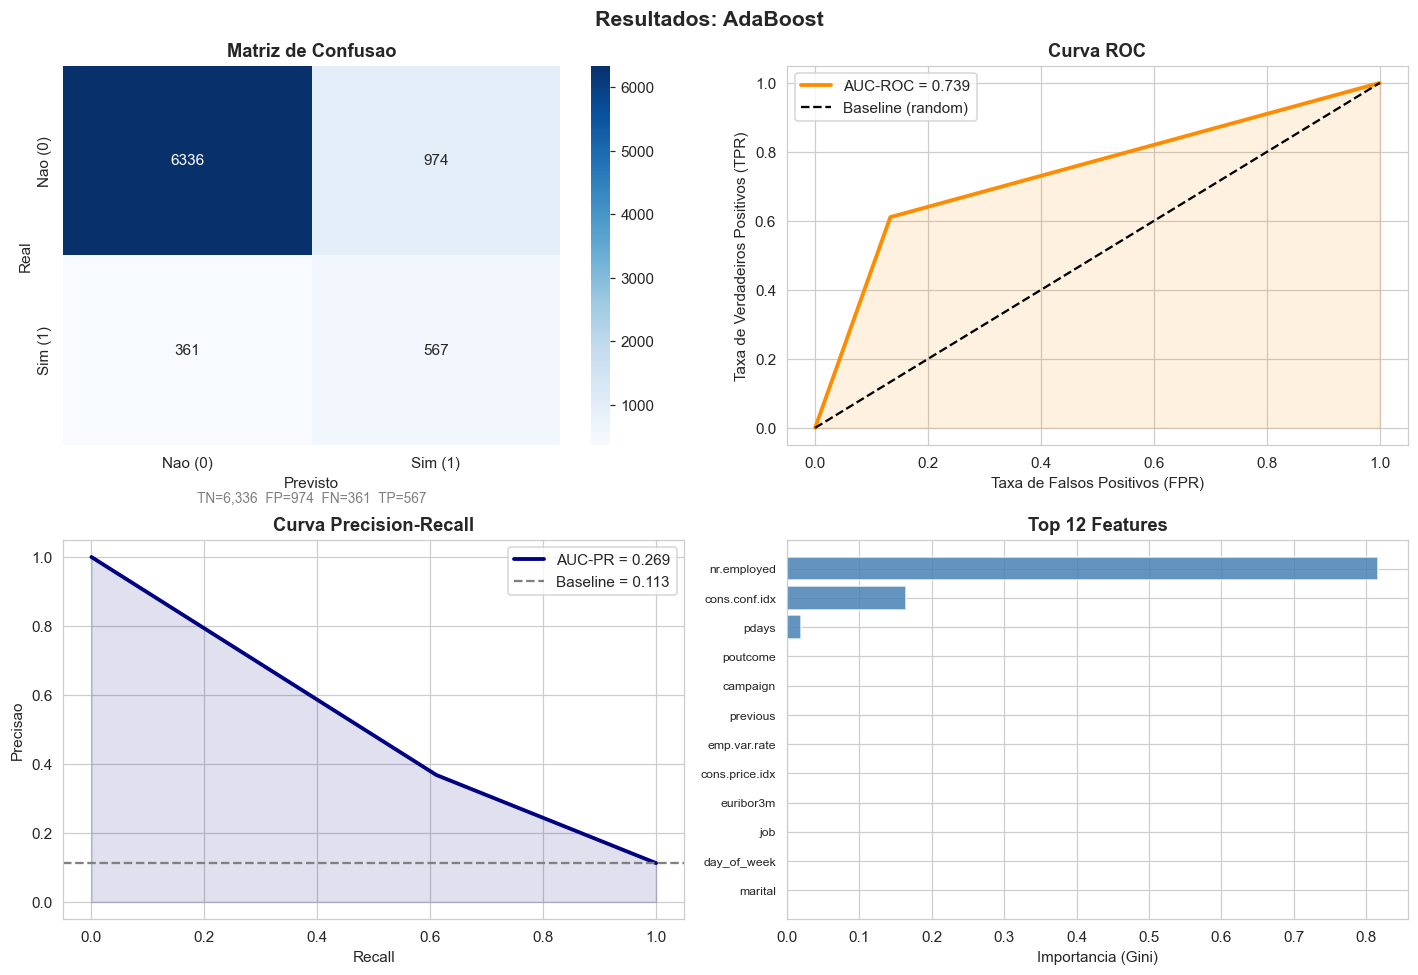


RELATORIO — AdaBoost  |  Treino: 0.11s
              precision    recall  f1-score   support

     Nao (0)       0.95      0.87      0.90      7310
     Sim (1)       0.37      0.61      0.46       928

    accuracy                           0.84      8238
   macro avg       0.66      0.74      0.68      8238
weighted avg       0.88      0.84      0.85      8238

AUC-ROC : 0.7389
AUC-PR  : 0.2686


In [13]:
# ─── AdaBoost ────────────────────────────────────────────────────────────────
clf_ada = AdaBoostClassifier(
    estimator=DecisionTreeClassifier(max_depth=2, class_weight="balanced"),
    n_estimators=200,
    learning_rate=0.5,
    random_state=42,
)
clf_ada = avaliar(clf_ada, "AdaBoost")

---
# 11. 🎲 Naive Bayes (GaussianNB)

## Teoria

Os classificadores **Naive Bayes** aplicam o Teorema de Bayes com a suposição "ingênua"
de **independência condicional** entre as features, dado o rótulo:

```
P(y | x₁, x₂, ..., xₙ) ∝ P(y) × P(x₁|y) × P(x₂|y) × ... × P(xₙ|y)
```

O **GaussianNB** assume que cada feature, dentro de cada classe, segue uma
distribuição Normal (Gaussiana):

```
P(xⱼ | y=k) = (1/√(2πσ²ₖⱼ)) × exp(-(xⱼ - μₖⱼ)² / (2σ²ₖⱼ))
```

Classificamos a nova observação na classe k que maximiza o produto acima.

## Vantagens
- **Extremamente rápido** — treinamento O(n×d) e predição O(k×d)
- Funciona bem com poucos dados de treinamento
- Lida naturalmente com alta dimensionalidade
- Útil como baseline rápido

## Desvantagens
- A suposição de independência condicional **raramente é verdade** na prática
  (features correlacionadas violam a suposição)
- Para dados numéricos, assume distribuição Gaussiana (pode não ser válido)
- Sem suporte a `class_weight` — usa os `priors` das classes observadas

## Parâmetros Principais

| Parâmetro | Descrição | Valor usado |
|---|---|---|
| `var_smoothing` | Adicionado à variância para estabilidade numérica | 1e-9 (padrão) |
| `priors` | Probabilidades a priori das classes | `None` (usa frequências do treino) |

> ⚠️ **Atenção:** Sem `class_weight`, o Naive Bayes usa as proporções reais das classes
> (88,7% não / 11,3% sim) como prior. Compare os resultados com os outros modelos.

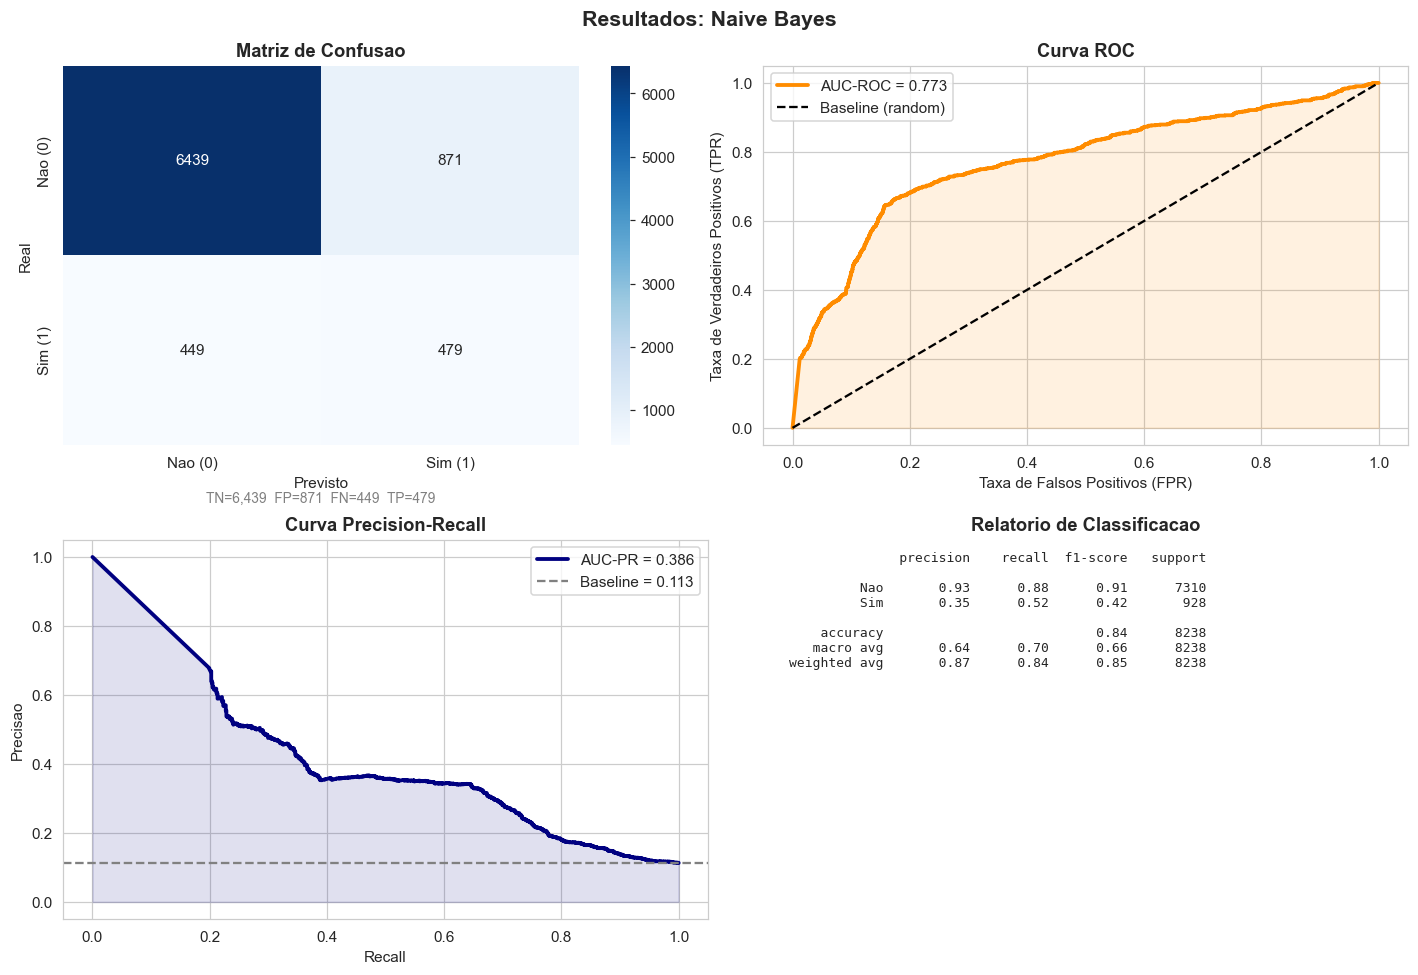


RELATORIO — Naive Bayes  |  Treino: 0.02s
              precision    recall  f1-score   support

     Nao (0)       0.93      0.88      0.91      7310
     Sim (1)       0.35      0.52      0.42       928

    accuracy                           0.84      8238
   macro avg       0.64      0.70      0.66      8238
weighted avg       0.87      0.84      0.85      8238

AUC-ROC : 0.7731
AUC-PR  : 0.3861


In [14]:
# ─── Naive Bayes (GaussianNB) ─────────────────────────────────────────────────
clf_nb = GaussianNB()
clf_nb = avaliar(clf_nb, "Naive Bayes")

---
# 12. ⚡ XGBoost — Extreme Gradient Boosting

## Teoria

O **XGBoost** é um método de boosting baseado em **Gradient Boosting** com otimizações
de software e hardware que o tornam extremamente eficiente. A analogia das entrevistas
ajuda a entender a evolução:

| Algoritmo | Analogia |
|---|---|
| Árvore de Decisão | Um único entrevistador com seus critérios |
| Bagging / RF | Um painel de entrevistadores votando democraticamente |
| Boosting | Cada entrevistador aprende com os erros do anterior |
| Gradient Boosting | Minimiza os erros usando descida do gradiente |
| **XGBoost** | Gradient Boosting com otimizações extremas + regularização |

O XGBoost minimiza uma **função objetivo** que inclui a perda preditiva E um termo
de regularização para controlar a complexidade:

```
Obj = Σᵢ L(yᵢ, ŷᵢ) + Σₖ Ω(fₖ)    onde Ω(f) = γT + ½λ||w||²
```

Em cada iteração, uma nova árvore é adicionada para corrigir os **resíduos** da iteração anterior.

## Vantagens
- Estado da arte em muitas competições de dados (Kaggle)
- Regularização nativa (L1 e L2 nas folhas)
- Lida eficientemente com dados esparsos
- **Muito rápido** com paralelização via `n_jobs`
- Feature importance altamente informativa

## Desvantagens
- Muitos hiperparâmetros para ajustar
- Propenso a overfitting se não regularizado adequadamente
- Menos interpretável que árvore simples

## Parâmetros Principais

| Parâmetro | Descrição | Valor usado |
|---|---|---|
| `n_estimators` | Número de árvores | 300 |
| `max_depth` | Profundidade máxima | 6 |
| `learning_rate` | Eta — step size por iteração | 0.1 |
| `subsample` | Fração de linhas por árvore | 0.8 |
| `colsample_bytree` | Fração de features por árvore | 0.8 |
| `scale_pos_weight` | Compensa desbalanceamento | neg/pos ≈ 7.8 |
| `use_label_encoder` | Evitar aviso do XGBoost | `False` |

scale_pos_weight = 29238/3712 = 7.88


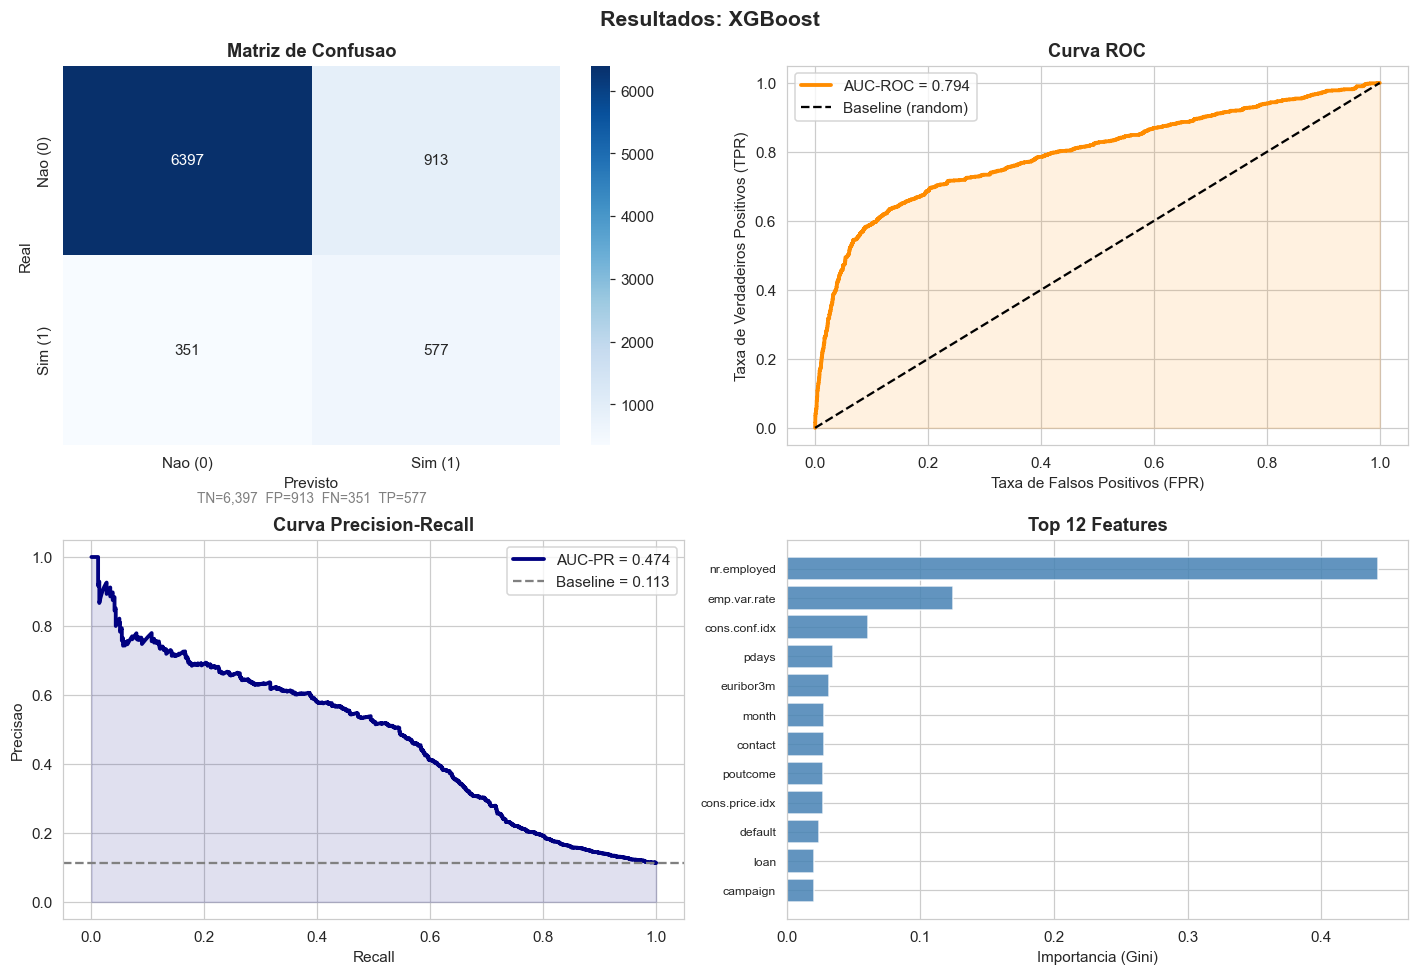


RELATORIO — XGBoost  |  Treino: 0.62s
              precision    recall  f1-score   support

     Nao (0)       0.95      0.88      0.91      7310
     Sim (1)       0.39      0.62      0.48       928

    accuracy                           0.85      8238
   macro avg       0.67      0.75      0.69      8238
weighted avg       0.88      0.85      0.86      8238

AUC-ROC : 0.7941
AUC-PR  : 0.4740


In [15]:
# ─── XGBoost ──────────────────────────────────────────────────────────────────
if not XGB_OK:
    print("XGBoost nao disponivel. Instale com: pip install xgboost")
else:
    # scale_pos_weight = n_negativos / n_positivos (compensa desbalanceamento)
    neg = (y_train == 0).sum()
    pos = (y_train == 1).sum()
    spw = neg / pos
    print(f"scale_pos_weight = {neg}/{pos} = {spw:.2f}")

    clf_xgb = xgb.XGBClassifier(
        n_estimators=300,
        max_depth=6,
        learning_rate=0.1,
        subsample=0.8,
        colsample_bytree=0.8,
        scale_pos_weight=spw,
        use_label_encoder=False,
        eval_metric="logloss",
        n_jobs=-1,
        random_state=42,
    )
    clf_xgb = avaliar(clf_xgb, "XGBoost")

---
# 13. 📊 Comparação Geral dos Modelos

Agora que todos os modelos foram treinados, vamos comparar seu desempenho de forma
objetiva usando a tabela de resultados, as curvas ROC sobrepostas e as curvas
Precision-Recall sobrepostas.

**Critério de ranking:** AUC-PR (Área sob a curva Precision-Recall) — a métrica mais
adequada para datasets desbalanceados como o Bank Marketing.

In [16]:
# ─── Tabela Comparativa ───────────────────────────────────────────────────────
df_res = pd.DataFrame(results_table).T.reset_index().rename(columns={"index": "Modelo"})
df_res = df_res.sort_values("AUC-PR", ascending=False).reset_index(drop=True)
df_res.index = df_res.index + 1   # ranking começa em 1

print("RANKING DOS MODELOS — ordenado por AUC-PR (metrica principal)")
print("="*70)

# Estilo
def highlight_max_col(s):
    is_max = s == s.max()
    return ["background-color: #c8e6c9; font-weight:bold" if v else "" for v in is_max]

styled = (df_res.style
          .apply(highlight_max_col, subset=["Acuracia","Precisao(+)","Recall(+)",
                                            "F1(+)","AUC-ROC","AUC-PR"])
          .format({c: "{:.4f}" for c in ["Acuracia","Precisao(+)","Recall(+)",
                                          "F1(+)","AUC-ROC","AUC-PR"]})
          .set_caption("Verde = melhor valor por coluna"))
display(styled)
display(df_res)

RANKING DOS MODELOS — ordenado por AUC-PR (metrica principal)


,Modelo,Acuracia,Precisao(+),Recall(+),F1(+),AUC-ROC,AUC-PR,Tempo(s)
1,Random Forest,0.8682,0.4397,0.6207,0.5147,0.8163,0.4872,1.150000
2,XGBoost,0.8466,0.3872,0.6218,0.4773,0.7941,0.4740,0.620000
3,MLP Classifier,0.9023,0.6713,0.2597,0.3745,0.8014,0.4723,8.190000
4,Decision Tree,0.8538,0.4050,0.6336,0.4941,0.8023,0.4605,0.140000
5,Logistic Regression,0.8127,0.3321,0.6552,0.4407,0.7959,0.4530,0.080000
6,SVM Linear,0.8359,0.3662,0.6250,0.4618,0.7893,0.4334,224.100000
7,Naive Bayes,0.8398,0.3548,0.5162,0.4205,0.7731,0.3861,0.020000
8,SVM RBF,0.8458,0.3882,0.6401,0.4833,0.7812,0.3691,39.920000
9,KNN (K=7),0.8923,0.5428,0.2802,0.3696,0.7287,0.3415,0.010000
10,AdaBoost,0.8379,0.3679,0.6110,0.4593,0.7389,0.2686,0.110000


,Modelo,Acuracia,Precisao(+),Recall(+),F1(+),AUC-ROC,AUC-PR,Tempo(s)
1,Random Forest,0.8682,0.4397,0.6207,0.5147,0.8163,0.4872,1.15
2,XGBoost,0.8466,0.3872,0.6218,0.4773,0.7941,0.4740,0.62
3,MLP Classifier,0.9023,0.6713,0.2597,0.3745,0.8014,0.4723,8.19
4,Decision Tree,0.8538,0.4050,0.6336,0.4941,0.8023,0.4605,0.14
5,Logistic Regression,0.8127,0.3321,0.6552,0.4407,0.7959,0.4530,0.08
6,SVM Linear,0.8359,0.3662,0.6250,0.4618,0.7893,0.4334,224.10
7,Naive Bayes,0.8398,0.3548,0.5162,0.4205,0.7731,0.3861,0.02
8,SVM RBF,0.8458,0.3882,0.6401,0.4833,0.7812,0.3691,39.92
9,KNN (K=7),0.8923,0.5428,0.2802,0.3696,0.7287,0.3415,0.01
10,AdaBoost,0.8379,0.3679,0.6110,0.4593,0.7389,0.2686,0.11


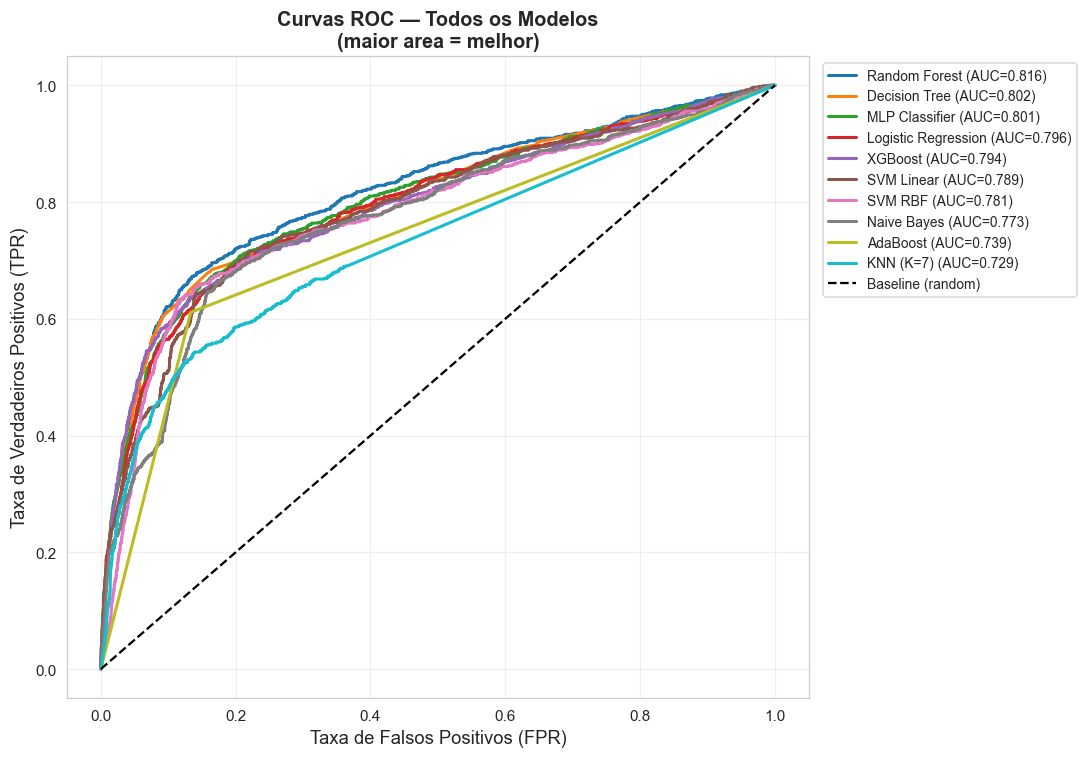

In [17]:
# ─── ROC Curves — Todos os Modelos ───────────────────────────────────────────
palette = sns.color_palette("tab10", n_colors=len(roc_curves))
roc_sorted = sorted(roc_curves.items(), key=lambda x: -x[1][2])

fig, ax = plt.subplots(figsize=(10, 7))
for i, (name, (fpr, tpr, auc_v)) in enumerate(roc_sorted):
    ax.plot(fpr, tpr, lw=2, label=f"{name} (AUC={auc_v:.3f})",
            color=palette[i])
ax.plot([0,1],[0,1], "k--", lw=1.5, label="Baseline (random)")
ax.set_xlabel("Taxa de Falsos Positivos (FPR)", fontsize=12)
ax.set_ylabel("Taxa de Verdadeiros Positivos (TPR)", fontsize=12)
ax.set_title("Curvas ROC — Todos os Modelos\n(maior area = melhor)",
             fontsize=13, fontweight="bold")
ax.legend(fontsize=9, bbox_to_anchor=(1.01, 1), loc="upper left")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("fig_roc_comparison.png", dpi=150, bbox_inches="tight")
plt.show(); plt.close()

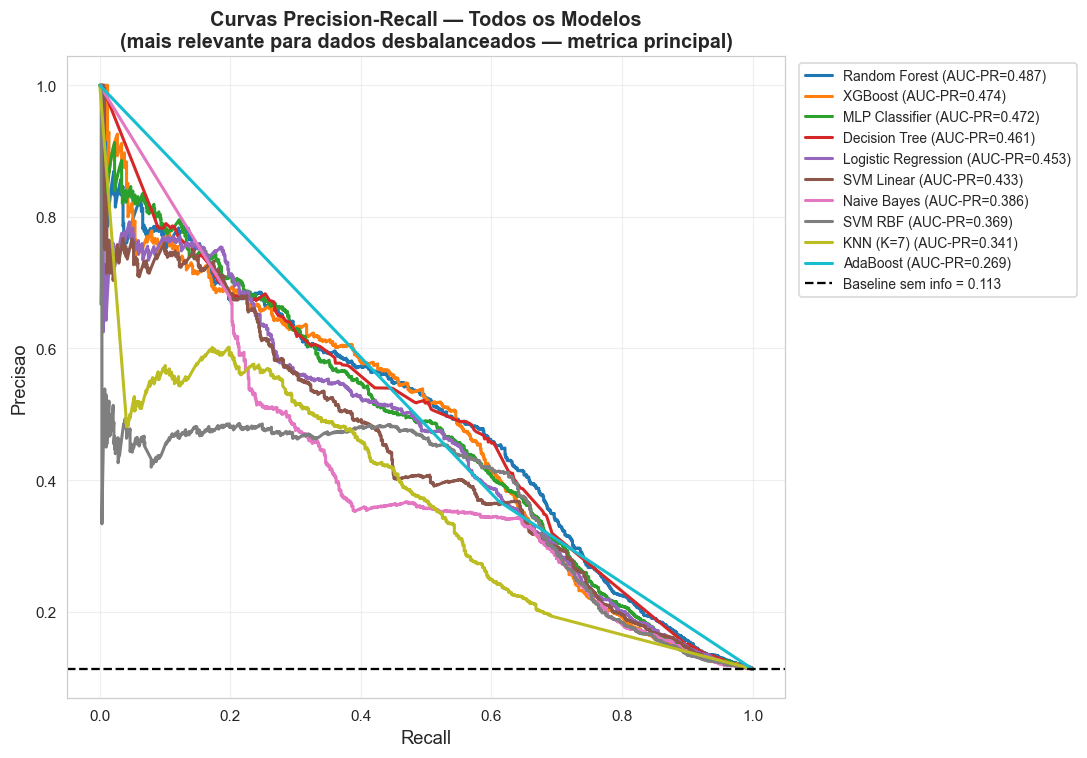

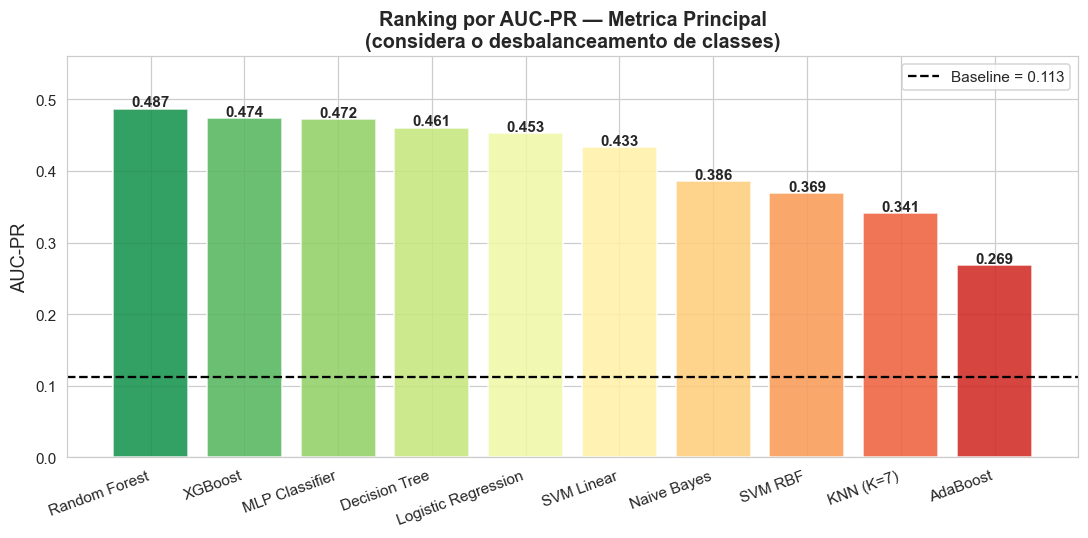

In [18]:
# ─── Precision-Recall Curves — Todos os Modelos ──────────────────────────────
pr_sorted  = sorted(pr_curves.items(), key=lambda x: -x[1][2])
baseline_pr = y_test.mean()

fig, ax = plt.subplots(figsize=(10, 7))
for i, (name, (prec, rec, ap)) in enumerate(pr_sorted):
    ax.plot(rec, prec, lw=2, label=f"{name} (AUC-PR={ap:.3f})",
            color=palette[i])
ax.axhline(baseline_pr, color="black", ls="--", lw=1.5,
           label=f"Baseline sem info = {baseline_pr:.3f}")
ax.set_xlabel("Recall", fontsize=12)
ax.set_ylabel("Precisao", fontsize=12)
ax.set_title("Curvas Precision-Recall — Todos os Modelos\n"
             "(mais relevante para dados desbalanceados — metrica principal)",
             fontsize=13, fontweight="bold")
ax.legend(fontsize=9, bbox_to_anchor=(1.01, 1), loc="upper left")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("fig_pr_comparison.png", dpi=150, bbox_inches="tight")
plt.show(); plt.close()

# Bar chart de AUC-PR
fig2, ax2 = plt.subplots(figsize=(10, 5))
nomes = [n for n, _ in pr_sorted]
aps   = [ap for _, (_, _, ap) in pr_sorted]
cores_bar = sns.color_palette("RdYlGn", n_colors=len(nomes))[::-1]
bars = ax2.bar(nomes, aps, color=cores_bar, alpha=0.88, edgecolor="white")
ax2.axhline(baseline_pr, color="black", ls="--", lw=1.5,
            label=f"Baseline = {baseline_pr:.3f}")
for b, v in zip(bars, aps):
    ax2.text(b.get_x()+b.get_width()/2, b.get_height()+0.003,
             f"{v:.3f}", ha="center", fontsize=10, fontweight="bold")
ax2.set_ylabel("AUC-PR", fontsize=12)
ax2.set_title("Ranking por AUC-PR — Metrica Principal\n"
              "(considera o desbalanceamento de classes)",
              fontsize=13, fontweight="bold")
ax2.legend(fontsize=10)
ax2.set_ylim(0, max(aps)*1.15)
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.savefig("fig_aucpr_ranking.png", dpi=150, bbox_inches="tight")
plt.show(); plt.close()

---
# 14. 🎯 Conclusões

## Síntese dos Resultados

Este notebook aplicou **10 algoritmos de classificação** ao Bank Marketing Dataset,
um problema binário com forte desbalanceamento de classes (88,7% vs 11,3%).

### Por que a Acurácia Engana?

Um modelo que prevê **sempre "não"** teria acurácia de 88,7% — mas seria completamente
inútil para o banco, que quer identificar os clientes propensos a assinar. Por isso,
utilizamos **AUC-PR como métrica principal**.

### O que as Curvas Revelam?

- **Curva ROC:** todos os modelos não-triviais ficaram bem acima da diagonal (baseline).
  A curva ROC pode ser otimista em dados desbalanceados.

- **Curva Precision-Recall:** o desafio real fica evidente. Modelos de ensemble (Random
  Forest, XGBoost, AdaBoost) tendem a dominar nesta curva porque capturam relações
  não-lineares e interações entre features.

### Observações por Família de Modelos

| Família | Observação |
|---|---|
| **Ensemble (RF, XGBoost, AdaBoost)** | Melhor performance geral; XGBoost tende ao topo com `scale_pos_weight` |
| **Linear (LR, SVM Linear)** | Bons resultados, interpretáveis, rápidos — excelentes como baseline |
| **Baseado em Instâncias (KNN)** | Performance aceitável, mas sem suporte nativo a `class_weight` |
| **Rede Neural (MLP)** | Competitivo, mas requer mais ajuste de hiperparâmetros |
| **Probabilístico (NB)** | Mais rápido, mas penalizado pela suposição de independência |
| **Árvore Simples (DT)** | Interpretável, mas menos precisa — use como ferramenta explicativa |

## Limitações e Próximos Passos

1. **GridSearchCV / RandomizedSearchCV:** todos os modelos foram treinados com
   hiperparâmetros padrão — otimização pode melhorar significativamente os resultados.

2. **Técnicas de rebalanceamento:** SMOTE (Synthetic Minority Oversampling Technique)
   ou undersampling da classe majoritária podem complementar o `class_weight`.

3. **Stacking / Blending:** combinar as predições dos melhores modelos pode
   superar qualquer modelo individual.

4. **Interpretabilidade:** para deployment real, SHAP values permitem explicar
   as previsões do XGBoost ou Random Forest a nível de observação individual.

5. **Threshold customizado:** ajustar o threshold de decisão (padrão = 0,5) com
   base no custo real de FP vs FN para o negócio do call center.

---

> 💬 **Mensagem para os alunos:** Não existe um algoritmo universalmente superior.
> A escolha depende do problema, dos dados, das restrições computacionais e dos
> requisitos de interpretabilidade. Use este notebook como ponto de partida para
> experimentar e desenvolver intuição sobre quando cada família de modelos brilha.